# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of another two synthetic data generation models:
1. **CTAB GAN Plus** - Conditional Tabular GAN plus
2. **WGAN-GP** - Wassertian GAN with gradiant penalty

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


# Generating synthetic data

In [1]:
!git clone https://github.com/Team-TUD/CTAB-GAN-Plus
import sys
sys.path.append('./CTAB-GAN-Plus')
from model.ctabgan import CTABGAN

fatal: destination path 'CTAB-GAN-Plus' already exists and is not an empty directory.


In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from model.ctabgan import CTABGAN


# -----------------------------
# Load Concrete Compressive Strength dataset
# -----------------------------
concrete = fetch_ucirepo(id=165)
X = concrete.data.features
y = concrete.data.targets
print(concrete.metadata)
print(concrete.variables)

data = pd.concat([X, y], axis=1)
target_col = "Concrete compressive strength"

# Drop date/time/session/ID features before generator training (high cardinality).
_drop_feature_cols = [
    "Date", "Time", "date_time",
    "session_id", "Session ID", "Session_ID", "session",
    "X1 transaction date",
]
data = data.drop(columns=[c for c in _drop_feature_cols if c in data.columns], errors="ignore")

n_samples = min(1000, len(data))
data = data.sample(n=n_samples, random_state=42).reset_index(drop=True)

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(data[col].median())

target_col = "Concrete compressive strength"
X = data.drop(columns=[target_col])

# -----------------------------
# CTABGAN
# -----------------------------
data_path = "concrete_data_1000.csv"
data.to_csv(data_path, index=False)

categorical_columns = data.select_dtypes(include=["object", "category"]).columns.tolist()
integer_columns = X.select_dtypes(include=["int64", "int32"]).columns.tolist()

ctabgan = CTABGAN(
    raw_csv_path=data_path,
    categorical_columns=categorical_columns,
    log_columns=[],
    mixed_columns={},
    integer_columns=integer_columns,
    problem_type={"Regression": target_col}
)

ctabgan.fit()

synthetic_ctabgan = ctabgan.data_prep.inverse_prep(
    ctabgan.synthesizer.sample(1000)
)

# -----------------------------
# WGAN-GP
# -----------------------------
data_wgan = data.copy()

for col in data_wgan.columns:
    if data_wgan[col].dtype == "object":
        data_wgan[col] = data_wgan[col].fillna("Missing")
    else:
        data_wgan[col] = data_wgan[col].fillna(data_wgan[col].median())

label_encoders = {}
categorical_cols_wgan = data_wgan.select_dtypes(include=["object", "category"]).columns.tolist()

for col in categorical_cols_wgan:
    le = LabelEncoder()
    data_wgan[col] = le.fit_transform(data_wgan[col].astype(str))
    label_encoders[col] = le

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_wgan)
real_columns = data_wgan.columns

device = "cuda" if torch.cuda.is_available() else "cpu"
real_tensor = torch.tensor(scaled_data, dtype=torch.float32).to(device)

batch_size = 64
latent_dim = 32
data_dim = real_tensor.shape[1]
epochs = 30
critic_iterations = 2
lambda_gp = 10

train_loader = torch.utils.data.DataLoader(
    real_tensor, batch_size=batch_size, shuffle=True, drop_last=True
)


class Generator(nn.Module):
    def __init__(self, latent_dim, data_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, data_dim),
        )

    def forward(self, z):
        return self.model(z)


class Critic(nn.Module):
    def __init__(self, data_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.model(x)


generator = Generator(latent_dim, data_dim).to(device)
critic = Critic(data_dim).to(device)

optimizer_G = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.9))
optimizer_C = optim.Adam(critic.parameters(), lr=0.0001, betas=(0.5, 0.9))


def gradient_penalty(critic, real_samples, fake_samples):
    bs = real_samples.size(0)
    alpha = torch.rand(bs, 1, device=device).expand_as(real_samples)
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    critic_interpolates = critic(interpolates)
    gradients = torch.autograd.grad(
        outputs=critic_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(critic_interpolates),
        create_graph=True,
        retain_graph=True,
    )[0]
    gradients = gradients.view(bs, -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()


for epoch in range(epochs):
    for i, real_batch in enumerate(train_loader):
        real_batch = real_batch.to(device)
        for _ in range(critic_iterations):
            z = torch.randn(real_batch.size(0), latent_dim, device=device)
            fake_batch = generator(z)
            critic_real = critic(real_batch).mean()
            critic_fake = critic(fake_batch.detach()).mean()
            gp = gradient_penalty(critic, real_batch, fake_batch.detach())
            critic_loss = -(critic_real - critic_fake) + lambda_gp * gp
            optimizer_C.zero_grad()
            critic_loss.backward()
            optimizer_C.step()

        z = torch.randn(real_batch.size(0), latent_dim, device=device)
        fake_batch = generator(z)
        g_loss = -critic(fake_batch).mean()
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

z = torch.randn(1000, latent_dim, device=device)
fake_tensor = generator(z).detach().cpu().numpy()
synthetic_wgan = pd.DataFrame(scaler.inverse_transform(fake_tensor), columns=real_columns)

for col, le in label_encoders.items():
    synthetic_wgan[col] = le.inverse_transform(
        synthetic_wgan[col].round().astype(int).clip(0, len(le.classes_) - 1)
    )

synthetic_outputs = {
    "CTABGAN": synthetic_ctabgan,
    "WGAN_GP": synthetic_wgan,
}


{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C

100%|██████████| 150/150 [19:56<00:00,  7.98s/it]


Finished training in 1204.8074262142181  seconds.


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 643.33it/s]|
Column Shapes Score: 77.23%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 269.96it/s]|
Column Pair Trends Score: 69.72%

Overall Score (Average): 73.47%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 928.22it/s]|
Column Shapes Score: 74.43%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 365.92it/s]|
Column Pair Trends Score: 75.8%

Overall Score (Average): 75.12%



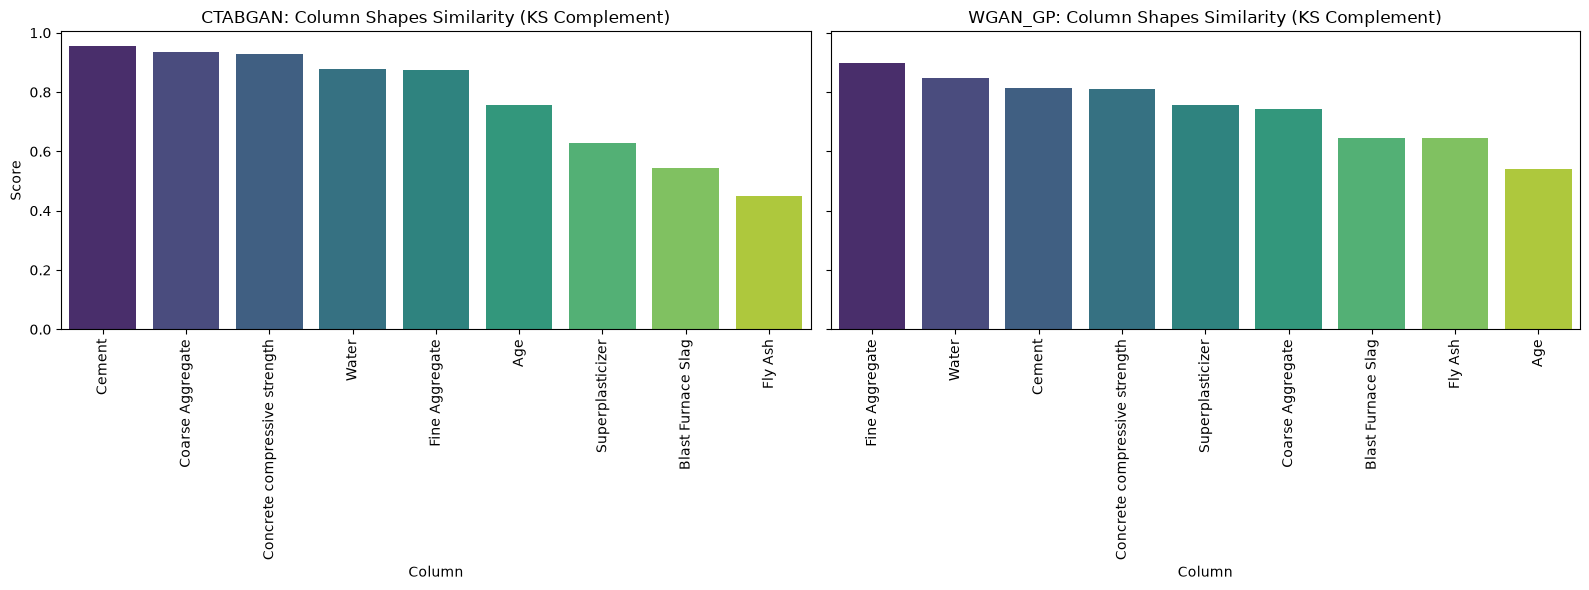

,Model,Average_Column_Shapes_Score
0,CTABGAN,0.772333
1,WGAN_GP,0.744333


,Column,Metric,Score,Model
0,Cement,KSComplement,0.957,CTABGAN
1,Coarse Aggregate,KSComplement,0.936,CTABGAN
2,Concrete compressive strength,KSComplement,0.928,CTABGAN
3,Water,KSComplement,0.877,CTABGAN
4,Fine Aggregate,KSComplement,0.875,CTABGAN
5,Age,KSComplement,0.757,CTABGAN
6,Superplasticizer,KSComplement,0.629,CTABGAN
7,Blast Furnace Slag,KSComplement,0.544,CTABGAN
8,Fly Ash,KSComplement,0.448,CTABGAN
9,Fine Aggregate,KSComplement,0.897,WGAN_GP


In [4]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

model_order = ["CTABGAN", "WGAN_GP"]
column_shape_details = {}
summary_rows = []

for model_name in model_order:
    qr = QualityReport()
    qr.generate(
        real_data=data,
        synthetic_data=synthetic_outputs[model_name],
        metadata=metadata.to_dict()
    )

    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

    summary_rows.append({
        "Model": model_name,
        "Average_Column_Shapes_Score": float(details["Score"].mean())
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Average_Column_Shapes_Score", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column",
        y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

display(summary_df)

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))

### 1.2. Jensen–Shannon divergence

In [5]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


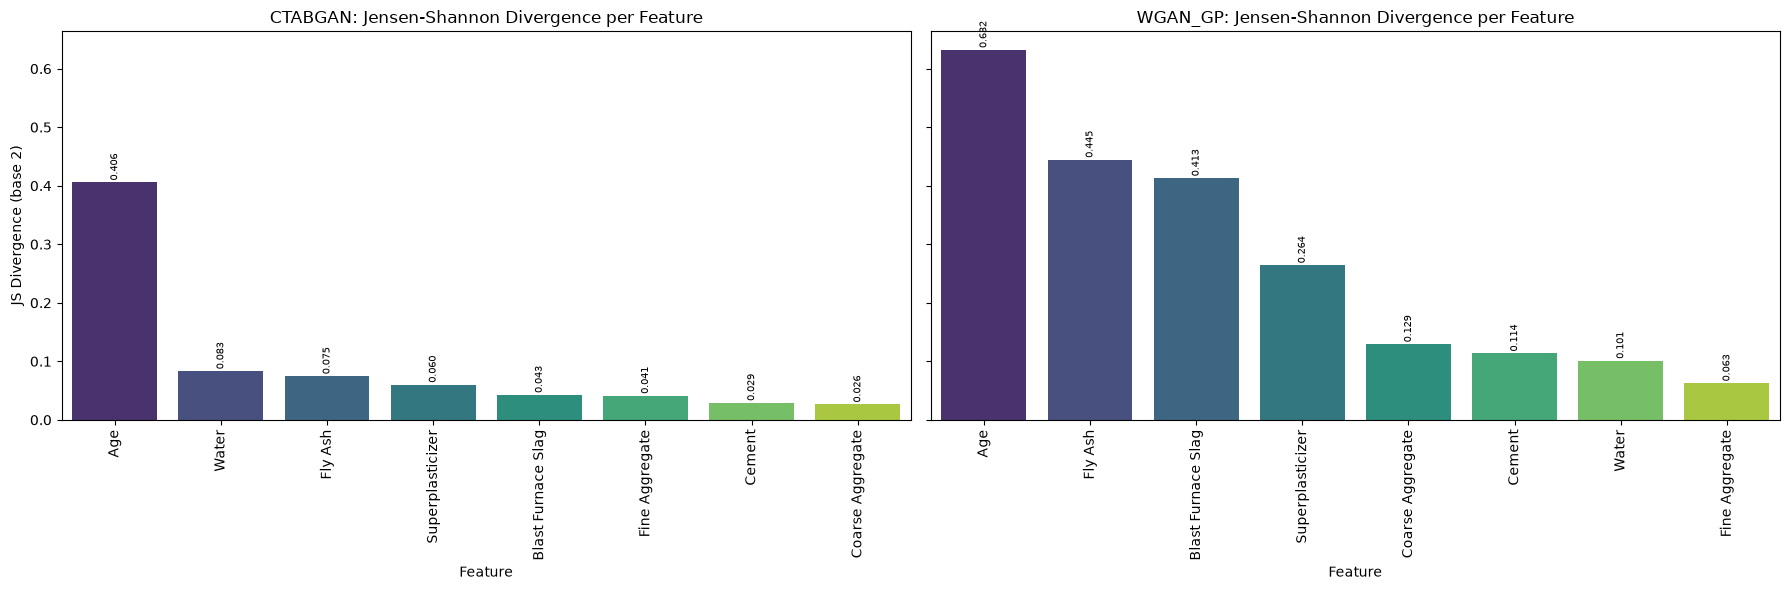

,Feature,JS_Divergence,Model
0,Age,0.405772,CTABGAN
1,Water,0.083282,CTABGAN
2,Fly Ash,0.074803,CTABGAN
3,Superplasticizer,0.060348,CTABGAN
4,Blast Furnace Slag,0.042813,CTABGAN
5,Fine Aggregate,0.041362,CTABGAN
6,Cement,0.029240,CTABGAN
7,Coarse Aggregate,0.026446,CTABGAN
8,Age,0.632215,WGAN_GP
9,Fly Ash,0.444603,WGAN_GP


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# remove target column from the comparison
real_df = data.drop(columns=[target_col], axis = 1)

model_order = ["CTABGAN", "WGAN_GP"]
js_results_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col])
    js_df = compute_js_divergence(
        real_df,
        synth_df,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTABGAN - Wasserstein Distance:
Cement: 0.0159
Blast Furnace Slag: 0.0699
Fly Ash: 0.1368
Water: 0.0293
Superplasticizer: 0.0514
Coarse Aggregate: 0.0252
Fine Aggregate: 0.0382
Age: 0.0265

WGAN_GP - Wasserstein Distance:
Cement: 0.0769
Blast Furnace Slag: 0.1396
Fly Ash: 0.1467
Water: 0.0379
Superplasticizer: 0.1269
Coarse Aggregate: 0.1409
Fine Aggregate: 0.0224
Age: 0.1088

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,CTABGAN,0.049142,0.033736,0.136797
1,WGAN_GP,0.100008,0.117857,0.146657


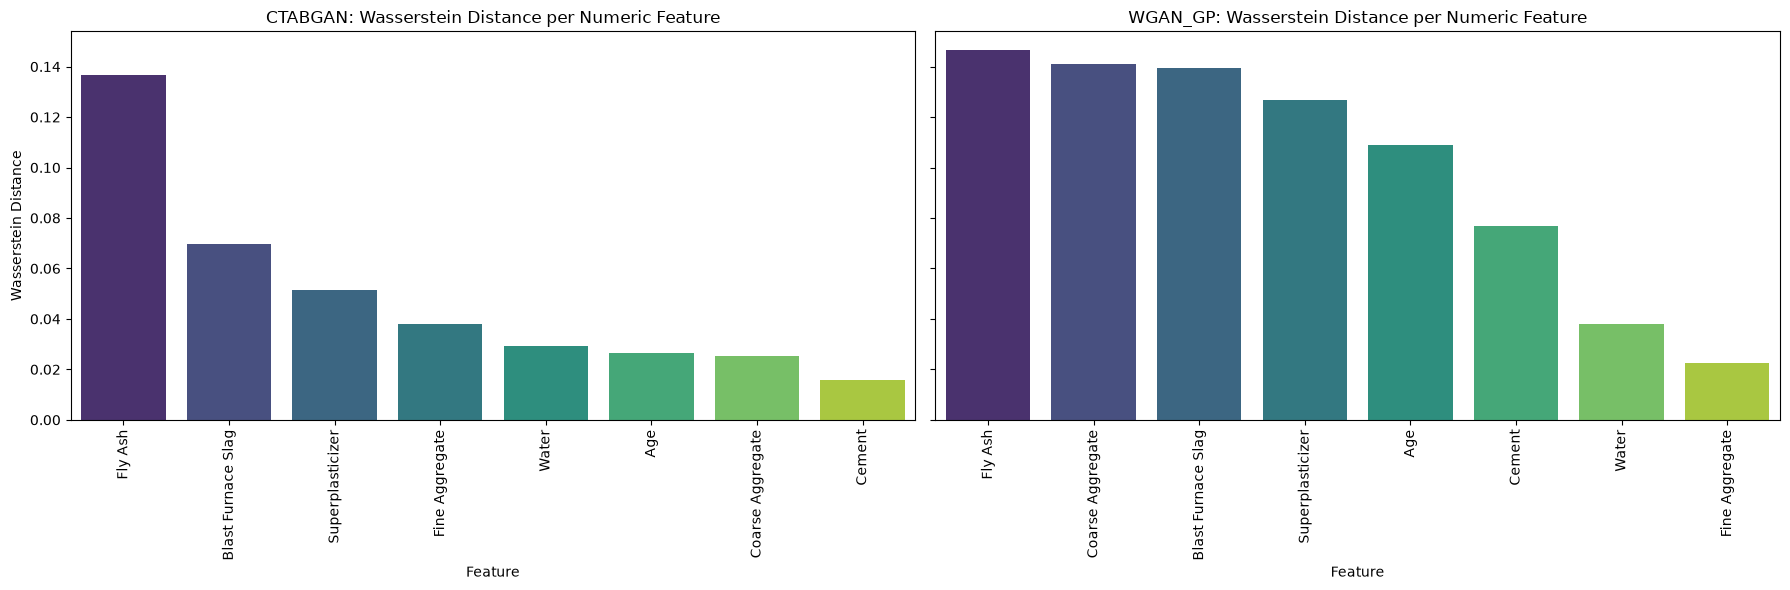

In [7]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for np.number

model_order = ["CTABGAN", "WGAN_GP"]

# Get the target column name (it's 'y' as per the kernel state)
# Assuming 'target_col' is available from previous cells.
# If not, it would need to be defined here. For this context, it is 'y'.
target_col = "Concrete compressive strength"

# Remove target variable from real data
real_df_for_metrics = data.drop(columns=[target_col])

# Identify numeric columns for scaling and Wasserstein distance calculation
numeric_cols = real_df_for_metrics.select_dtypes(include=np.number).columns.tolist()

# Create a DataFrame containing only numeric columns from the real data
real_numeric_df = real_df_for_metrics[numeric_cols]

scaler = MinMaxScaler()
# Fit and transform only the numeric columns of the real data
real_scaled_numeric = pd.DataFrame(
    scaler.fit_transform(real_numeric_df),
    columns=numeric_cols,
    index=real_numeric_df.index
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    # Drop the target column from synthetic data
    synth_df_for_metrics = synthetic_outputs[model_name].drop(columns=[target_col])

    # Ensure synthetic data has the same numeric columns as real data
    # and in the same order before scaling
    synth_numeric_df = synth_df_for_metrics[numeric_cols]

    # Transform synthetic numeric columns using the *same scaler* fitted on real data
    synthetic_scaled_numeric = pd.DataFrame(
        scaler.transform(synth_numeric_df),
        columns=numeric_cols,
        index=synth_numeric_df.index
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    # Calculate Wasserstein distance only for numeric columns
    for col in numeric_cols:
        dist = wasserstein_distance(real_scaled_numeric[col], synthetic_scaled_numeric[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(
        dists,
        columns=["Feature", "Wasserstein_Distance"]
    ).sort_values("Wasserstein_Distance", ascending=False)

    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Numeric Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [8]:
pip install gower

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "Concrete compressive strength"

X_real = data.drop(columns=[target_col], errors="ignore")

gower_results = []

for model_name in model_order:
    X_synth = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True)
    Xs = X_synth[common_cols].reset_index(drop=True)

    gower_real = 1 - gower.gower_matrix(Xr)
    gower_synth = 1 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = np.max(real_upper)
    avg_intra_real = np.mean(real_upper)
    max_intra_synth = np.max(synth_upper)
    avg_intra_synth = np.mean(synth_upper)

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = np.max(cross_block)
    avg_cross = np.mean(cross_block)

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTABGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7655

Intra-set Similarity (Synthetic):
Max = 0.9802, Avg = 0.7677

Cross-set Similarity (Real vs Synthetic):
Max = 0.9871, Avg = 0.7673

WGAN_GP - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.7655

Intra-set Similarity (Synthetic):
Max = 0.9807, Avg = 0.8177

Cross-set Similarity (Real vs Synthetic):
Max = 0.9812, Avg = 0.8306


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTABGAN,1.0,0.765455,0.980214,0.767685,0.987091,0.767293
1,WGAN_GP,1.0,0.765455,0.980673,0.817675,0.981152,0.830615


### 1.5 t-SNE Visualization


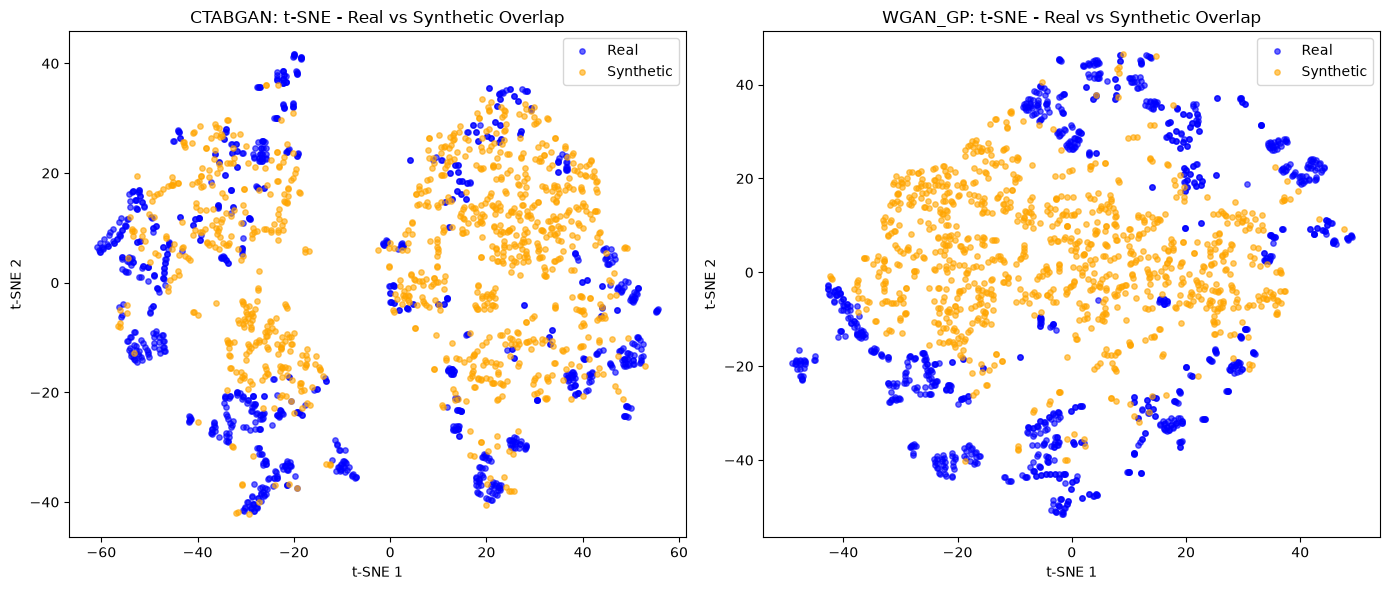

In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "Concrete compressive strength"

# remove target from real data
X_real = data.drop(columns=[target_col], errors="ignore")

# Select only numeric columns for scaling
numeric_cols = X_real.select_dtypes(include=np.number).columns
X_real_numeric = X_real[numeric_cols]

# scale real data once
scaler = MinMaxScaler()
real_scaled_numeric = pd.DataFrame(
    scaler.fit_transform(X_real_numeric),
    columns=numeric_cols
)

# create 1x2 t-SNE plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # keep same numeric columns/order for synthetic data
    synth_numeric = synth_df[numeric_cols]

    synthetic_scaled_numeric = pd.DataFrame(
        scaler.transform(synth_numeric),
        columns=numeric_cols
    )

    combined = np.vstack([real_scaled_numeric.values, synthetic_scaled_numeric.values])
    labels = np.array(["Real"] * len(real_scaled_numeric) + ["Synthetic"] * len(synthetic_scaled_numeric))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def gaussian_kernel(x, y, sigma=1.0):
    x_size = x.shape[0]
    y_size = y.shape[0]
    dim = x.shape[1]
    x_tile = np.tile(x, (y_size, 1))
    y_tile = np.repeat(y, x_size, axis=0)
    return np.exp(-np.sum((x_tile - y_tile) ** 2, axis=1) / (2 * dim * sigma ** 2)).reshape(y_size, x_size)

def compute_mmd(x, y, sigma=1.0):
    k_xx = np.mean(gaussian_kernel(x, x, sigma))
    k_yy = np.mean(gaussian_kernel(y, y, sigma))
    k_xy = np.mean(gaussian_kernel(x, y, sigma))
    return k_xx + k_yy - 2 * k_xy

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "Concrete compressive strength"

# Real features (exclude target)
real_features = data.drop(columns=[target_col], errors="ignore")

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # Align columns/order and select only numeric features
    common_numeric_cols = real_features.select_dtypes(include=np.number).columns.intersection(
        synth_df.select_dtypes(include=np.number).columns
    )
    X_real = real_features[common_numeric_cols]
    X_synth = synth_df[common_numeric_cols]

    # Standardize using real-data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = compute_mmd(X_real_scaled, X_synth_scaled, sigma=1.0)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.4f}")

# Lower MMD is better
mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTABGAN - MMD score: 0.0266
WGAN_GP - MMD score: 0.0699

MMD comparison (lower is better):


,Model,MMD_Score
0,CTABGAN,0.026633
1,WGAN_GP,0.069911


### 1.7 Cosine Similarity


In [12]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]
target_col = "Concrete compressive strength"

real_features = data.drop(columns=[target_col], errors="ignore")
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # Align columns/order and select only numeric features
    common_numeric_cols = real_features.select_dtypes(include=np.number).columns.intersection(
        synth_df.select_dtypes(include=np.number).columns
    )
    X_real = real_features[common_numeric_cols]
    X_synth = synth_df[common_numeric_cols]

    # Scale using real data stats
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    # Pairwise cross similarity: all real vs all synthetic rows
    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTABGAN - Sample-Level Similarity:
Average cosine similarity: 0.0012
Maximum cosine similarity: 0.9945

WGAN_GP - Sample-Level Similarity:
Average cosine similarity: 0.0134
Maximum cosine similarity: 0.9930

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,WGAN_GP,0.013373,0.992951
1,CTABGAN,0.001184,0.994516


### 1.8 Nearest Neighbours


In [13]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]

real_features = data.drop(columns=[target_col], errors="ignore")
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].drop(columns=[target_col], errors="ignore")

    # Align columns/order
    common_cols = real_features.columns.intersection(synth_df.columns)

    # Select only numeric columns from the common ones
    numeric_common_cols = common_cols.intersection(real_features.select_dtypes(include=np.number).columns)

    X_real_numeric = real_features[numeric_common_cols]
    X_synth_numeric = synth_df[numeric_common_cols]

    # Scale using real data statistics
    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real_numeric)
    X_synth_scaled = scaler.transform(X_synth_numeric)

    # Nearest-neighbor privacy check: Synthetic -> Real
    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTABGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.5105
Minimum NN Distance (Synthetic -> Real): 0.2441
5th Percentile NN Distance: 0.7001

WGAN_GP - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.0065
Minimum NN Distance (Synthetic -> Real): 0.4269
5th Percentile NN Distance: 1.1007

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,WGAN_GP,2.006543,0.426944,1.100692
1,CTABGAN,1.510459,0.244100,0.700076


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTABGAN,14.438487,7.034905,9.932629
1,WGAN_GP,26.940413,8.722670,23.580938


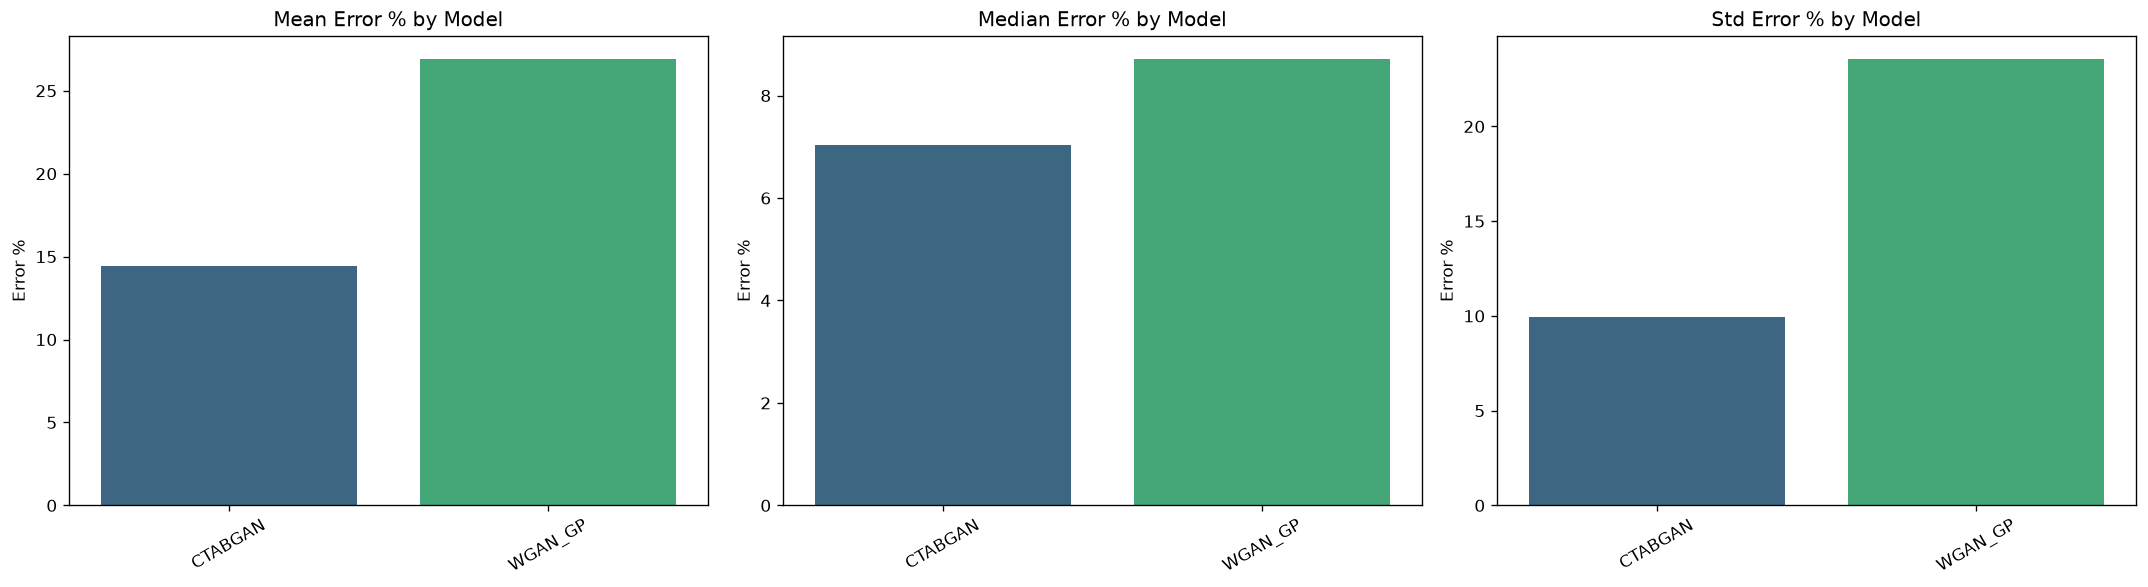

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "Concrete compressive strength" # Target column: Concrete compressive strength
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows).set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


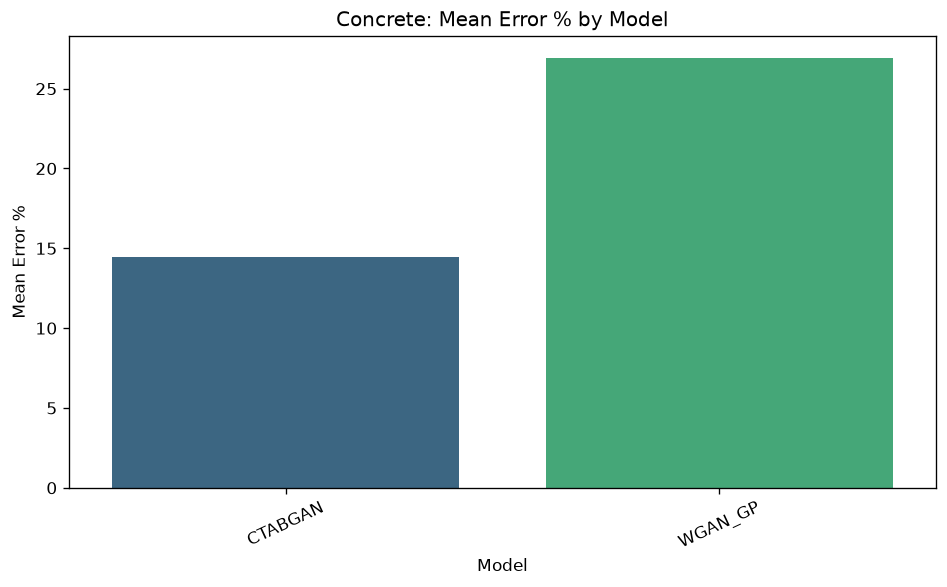

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Concrete: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


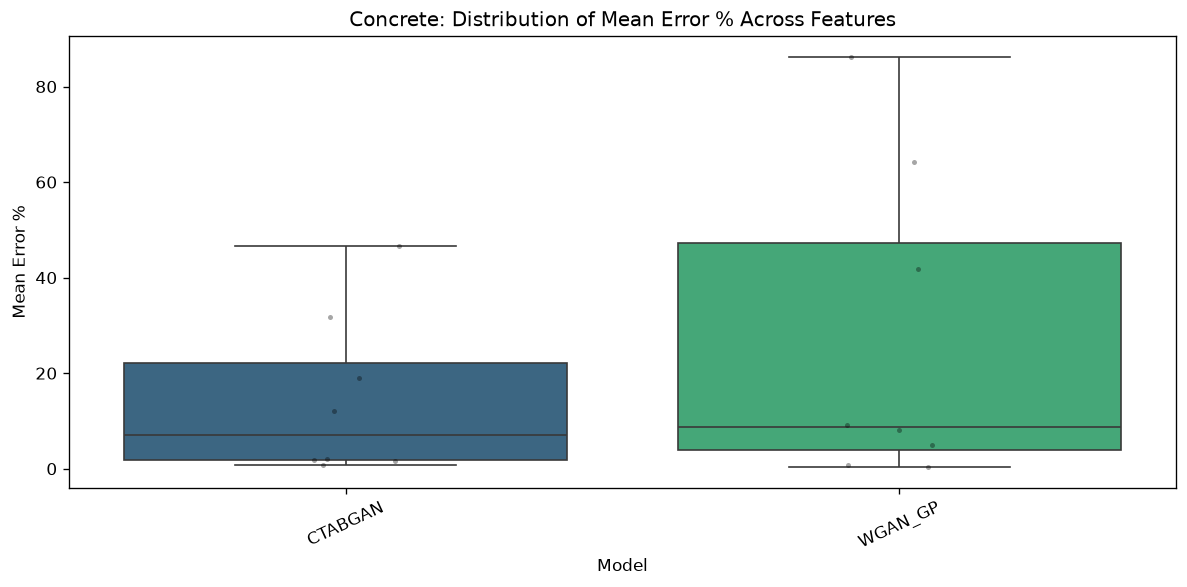

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_list = ["CTABGAN", "WGAN_GP"]
target_col = "Concrete compressive strength"
dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_list
        if m in feature_error_by_model
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Concrete: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


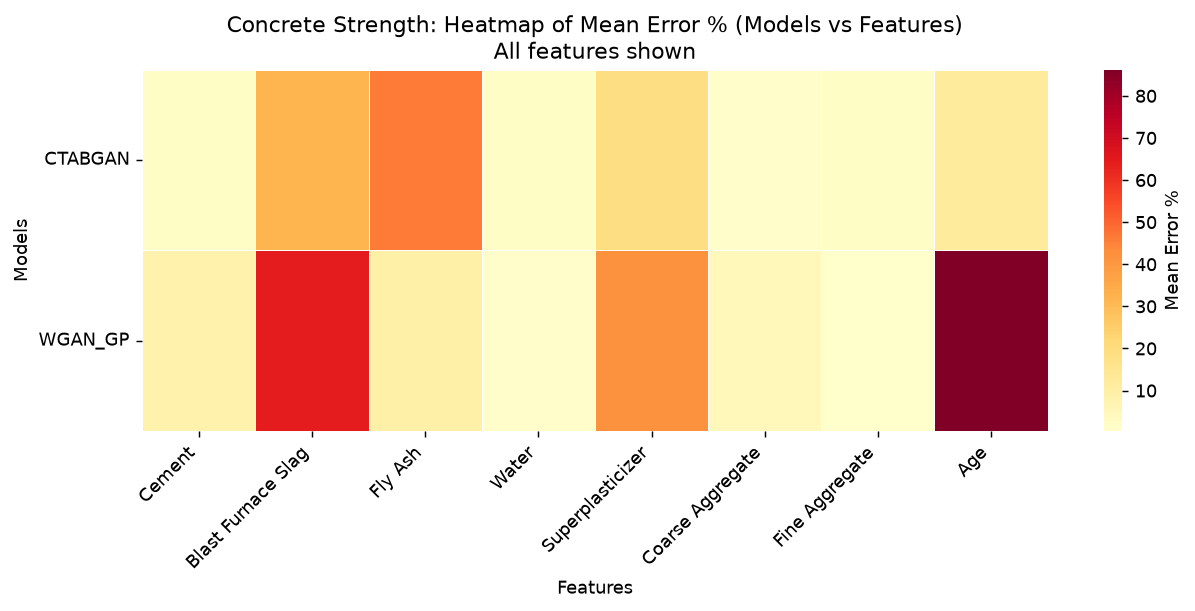

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Concrete Strength: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 2 Bivariate Analysis


In [18]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

def bivariate_quality(real_df, synth_df, target=None):
    """Compute bivariate quality metrics for cancer data."""

    if target is None:
        for cand in ["quality", "Class", "class", "target", "Target"]:
            if cand in real_df.columns:
                target = cand
                break

    if target is None or target not in real_df.columns or target not in synth_df.columns:
        # Instead of raising KeyError, return empty DFs if target is not found or not in both
        return pd.DataFrame(columns=["var_a", "var_b", "delta_corr"]), pd.DataFrame(columns=["feature", "delta_median_diff"])

    # Identify numeric columns for correlation analysis, excluding the target column
    num_cols = [
        c for c in real_df.columns
        if c != target and pd.api.types.is_numeric_dtype(real_df[c]) and pd.api.types.is_numeric_dtype(synth_df[c])
    ]

    # Prepare scaled data for correlation (only numeric features)
    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    if num_cols:
        real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
        synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    # For multi-class numeric target, calculate difference in class-wise medians
    results_target = []
    # Get all unique classes (levels) from the real target column
    unique_classes = sorted(real_df[target].unique())

    if len(unique_classes) > 1: # Only proceed if there are multiple classes
        for col in num_cols:
            real_medians = real_df.groupby(target)[col].median().reindex(unique_classes)
            synth_medians = synth_df.groupby(target)[col].median().reindex(unique_classes)

            # Calculate the absolute difference of medians for each class and average them
            diff_medians = np.abs(real_medians - synth_medians).mean()

            results_target.append({
                "feature": col,
                "delta_median_diff": diff_medians
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_median_diff", ascending=False) if results_target else pd.DataFrame(columns=["feature", "delta_median_diff"])

    return corr_df, target_df


In [19]:
import pandas as pd
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]

possible_targets = ["Concrete compressive strength"]
target_col = next((c for c in possible_targets if c in data.columns), None)

if target_col is None:
    raise KeyError(f"No target column found in data. Available columns: {list(data.columns)}")

real_df = data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # keep target column if it exists, but align numeric features separately inside the function
    if target_col not in synth_df.columns:
        raise KeyError(f"{target_col} not found in synthetic data for {model_name}")

    corr_results, target_results = bivariate_quality(
        real_df=real_df,
        synth_df=synth_df,
        target=target_col
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by diagnosis class:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next((c for c in ["delta_corr", "AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    # Updated to look for 'delta_median_diff' first, then 'delta_wasserstein' for backward compatibility if needed
    target_metric_col = next((c for c in ["delta_median_diff", "delta_wasserstein", "AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col and not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col and not corr_results.empty else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col and not target_results.empty and target_metric_col in target_results.columns else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col and not target_results.empty and target_metric_col in target_results.columns else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTABGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
18,Water,Superplasticizer,0.605698
20,Water,Fine Aggregate,0.420590
10,Blast Furnace Slag,Coarse Aggregate,0.336738
1,Cement,Fly Ash,0.323513
0,Cement,Blast Furnace Slag,0.308980
11,Blast Furnace Slag,Fine Aggregate,0.297705
7,Blast Furnace Slag,Fly Ash,0.280013
21,Water,Age,0.239152
22,Superplasticizer,Coarse Aggregate,0.235784
5,Cement,Fine Aggregate,0.228769


CTABGAN - Features that differ most by diagnosis class:


,feature,delta_median_diff
0,Cement,NaN
1,Blast Furnace Slag,NaN
2,Fly Ash,NaN
3,Water,NaN
4,Superplasticizer,NaN
5,Coarse Aggregate,NaN
6,Fine Aggregate,NaN
7,Age,NaN



WGAN_GP - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
19,Water,Coarse Aggregate,0.701016
3,Cement,Superplasticizer,0.594989
7,Blast Furnace Slag,Fly Ash,0.506937
1,Cement,Fly Ash,0.505052
18,Water,Superplasticizer,0.483916
25,Coarse Aggregate,Fine Aggregate,0.429066
0,Cement,Blast Furnace Slag,0.411145
9,Blast Furnace Slag,Superplasticizer,0.407511
26,Coarse Aggregate,Age,0.349153
12,Blast Furnace Slag,Age,0.299380


WGAN_GP - Features that differ most by diagnosis class:


,feature,delta_median_diff
0,Cement,NaN
1,Blast Furnace Slag,NaN
2,Fly Ash,NaN
3,Water,NaN
4,Superplasticizer,NaN
5,Coarse Aggregate,NaN
6,Fine Aggregate,NaN
7,Age,NaN


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTABGAN,0.605698,0.327694,NaN,NaN
1,WGAN_GP,0.701016,0.468816,NaN,NaN


### 3 Multivariate Analysis


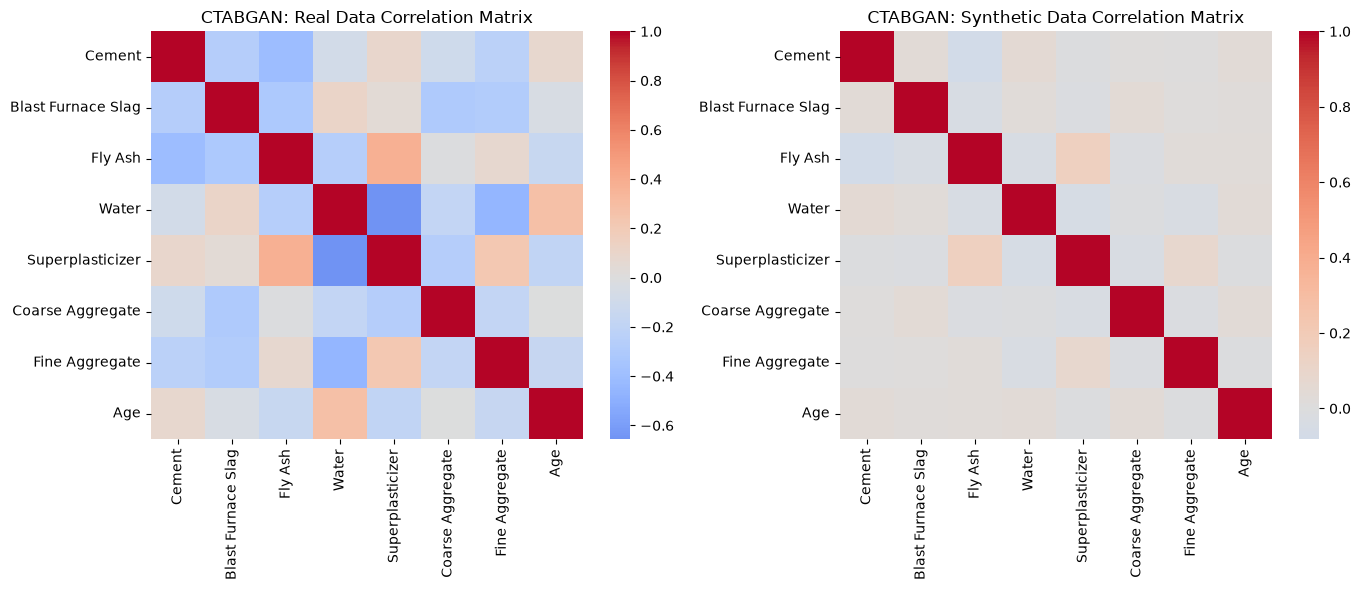

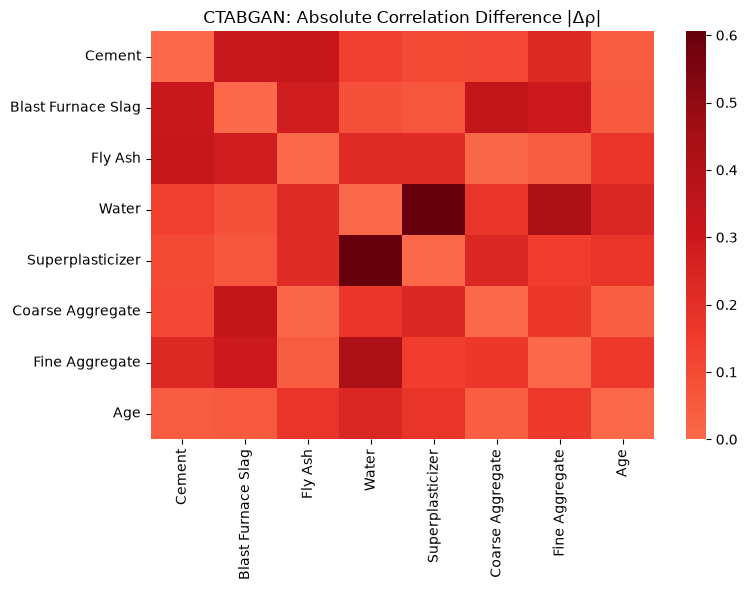

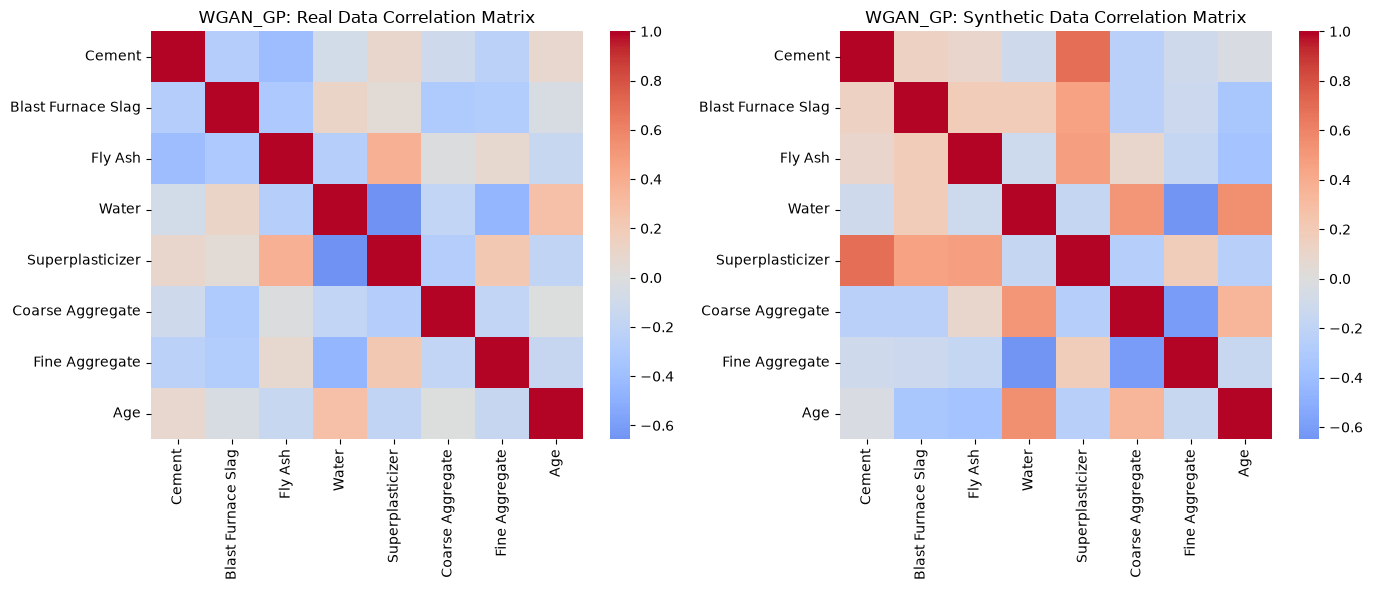

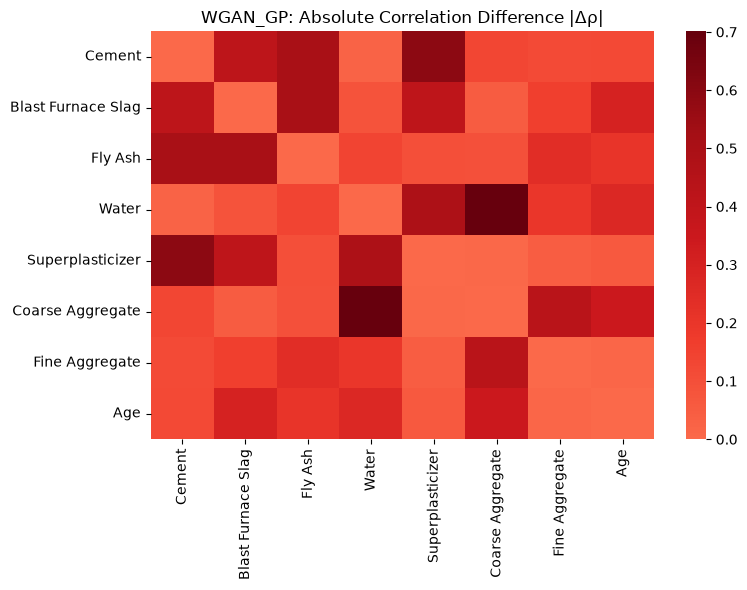

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "Concrete compressive strength"
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# remove target if it ended up in numeric columns
if target_col in num_cols:
    num_cols.remove(target_col)

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    # align columns safely
    common_cols = real_df.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]

    # keep only numeric columns for correlation
    synth_num_cols = [c for c in num_cols if c in synth_df.columns]
    synth_corr = synth_df[synth_num_cols].corr()

    # make sure both matrices use the same order
    common_num_cols = [c for c in num_cols if c in synth_corr.columns]
    real_corr_plot = real_corr.loc[common_num_cols, common_num_cols]
    synth_corr_plot = synth_corr.loc[common_num_cols, common_num_cols]

    # 1) Real vs Synthetic correlation matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr_plot, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr_plot, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    # 2) Absolute correlation difference heatmap
    diff_corr = (real_corr_plot - synth_corr_plot).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTABGAN - Global MMD (RBF): 0.019092


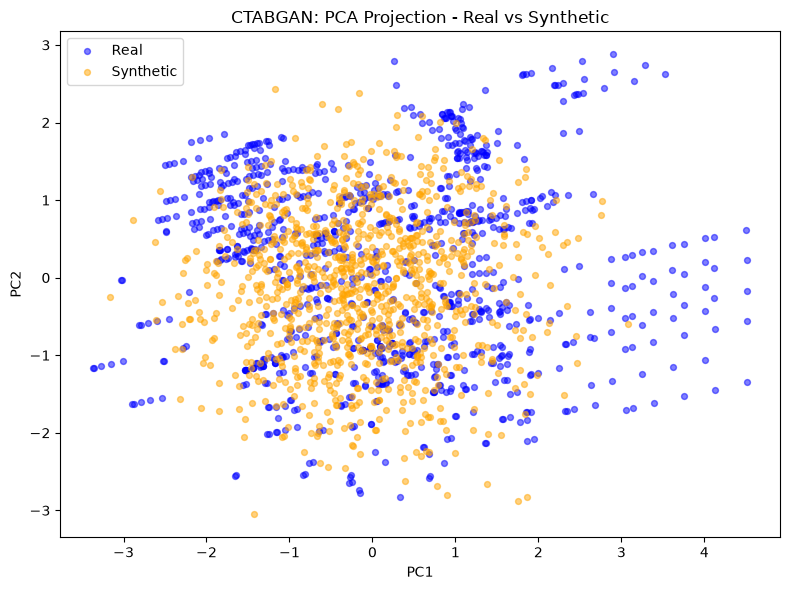

CTABGAN - Two-Sample Classifier Accuracy: 0.9224

WGAN_GP - Global MMD (RBF): 0.051293


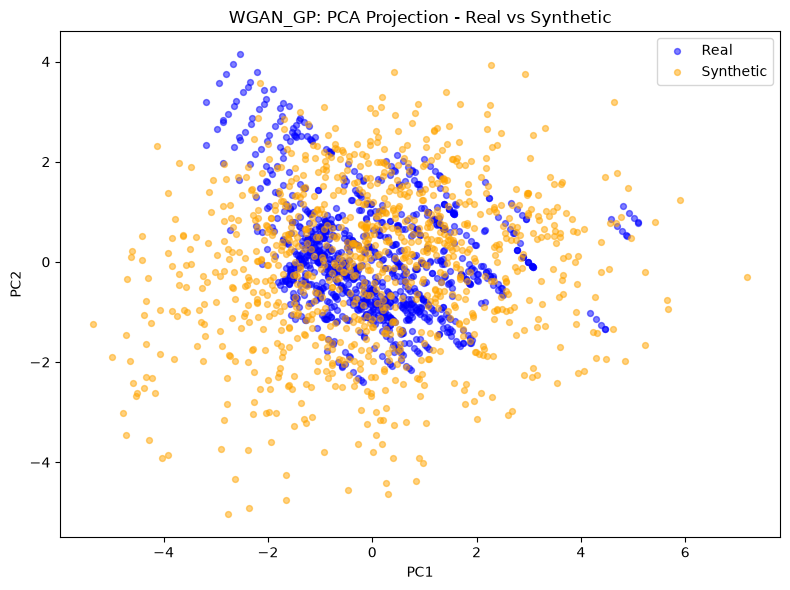

WGAN_GP - Two-Sample Classifier Accuracy: 0.9635

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,CTABGAN,0.019092,0.922392
1,WGAN_GP,0.051293,0.963480


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

model_order = ["CTABGAN", "WGAN_GP"]

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        dists = np.sqrt(((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2)) if med > 0 else 1.0
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

target_col = "Concrete compressive strength"
X_real_df = data.drop(columns=[target_col], errors="ignore")
X_real_df = X_real_df.select_dtypes(include=[np.number])

results = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    synth_df = synth_df.drop(columns=[target_col], errors="ignore")
    synth_df = synth_df.select_dtypes(include=[np.number])

    common_cols = X_real_df.columns.intersection(synth_df.columns)
    X_real = X_real_df[common_cols].values
    X_synth = synth_df[common_cols].values

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestRegressor(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = r2_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 regressors


In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'SVR-RBF': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(max_iter=2000, random_state=42)
}


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_models(train_df, test_df, label, models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label]).copy()
    y_train = train_df[label].copy()
    X_test = test_df.drop(columns=[label]).copy()
    y_test = test_df[label].copy()
    X_train, _, y_train, _ = train_test_split(X_train, y_train, test_size=test_size, random_state=seed)
    _, X_test, _, y_test = train_test_split(X_test, y_test, test_size=test_size, random_state=seed)
    num_cols = X_train.select_dtypes(include=[np.number]).columns
    X_train = X_train[num_cols].astype(np.float64)
    X_test = X_test[num_cols].astype(np.float64)
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results.append({"Model": name, "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)), "R2": r2_score(y_test, preds)})
    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


TRTR (Train Real, Test Real)


,Model,MAE,RMSE,R2
0,ExtraTrees,3.305280,4.990639,0.903506
1,GradientBoost,3.853346,5.157510,0.896946
2,RandomForest,3.586209,5.159141,0.896881
3,MLP,3.732953,5.198912,0.895285
4,DecisionTree,4.336200,6.756412,0.823145
5,KNN,6.929950,8.837354,0.697427
6,SVR-RBF,7.664849,9.874375,0.622250
7,Ridge,8.020439,10.296901,0.589230
8,LinearRegression,8.015265,10.299603,0.589014
9,Lasso,8.857823,10.994591,0.531679


CTABGAN - TSTR (Train Synthetic, Test Real)


,Model,MAE,RMSE,R2
0,LinearRegression,12.080218,15.094982,0.117223
1,Ridge,12.080795,15.095775,0.117130
2,SVR-RBF,12.036157,15.164299,0.109097
3,ElasticNet,12.522807,15.627498,0.053840
4,Lasso,12.559065,15.684999,0.046864
5,ExtraTrees,12.575824,15.695529,0.045584
6,MLP,12.789233,15.999121,0.008305
7,RandomForest,13.596429,16.490853,-0.053591
8,KNN,13.505095,17.108980,-0.134055
9,GradientBoost,13.906089,17.219643,-0.148772


CTABGAN - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,MAE_Diff,R2_Drop,Synthetic_Model
0,ExtraTrees,3.305280,4.990639,0.903506,12.575824,15.695529,0.045584,10.704890,9.270545,0.857922,CTABGAN
1,GradientBoost,3.853346,5.157510,0.896946,13.906089,17.219643,-0.148772,12.062133,10.052743,1.045718,CTABGAN
2,RandomForest,3.586209,5.159141,0.896881,13.596429,16.490853,-0.053591,11.331712,10.010220,0.950471,CTABGAN
3,MLP,3.732953,5.198912,0.895285,12.789233,15.999121,0.008305,10.800209,9.056280,0.886979,CTABGAN
4,DecisionTree,4.336200,6.756412,0.823145,16.355699,20.718089,-0.662973,13.961677,12.019499,1.486117,CTABGAN
5,KNN,6.929950,8.837354,0.697427,13.505095,17.108980,-0.134055,8.271626,6.575145,0.831482,CTABGAN
6,SVR-RBF,7.664849,9.874375,0.622250,12.036157,15.164299,0.109097,5.289924,4.371308,0.513152,CTABGAN
7,Ridge,8.020439,10.296901,0.589230,12.080795,15.095775,0.117130,4.798874,4.060356,0.472100,CTABGAN
8,LinearRegression,8.015265,10.299603,0.589014,12.080218,15.094982,0.117223,4.795379,4.064953,0.471791,CTABGAN
9,Lasso,8.857823,10.994591,0.531679,12.559065,15.684999,0.046864,4.690409,3.701242,0.484814,CTABGAN


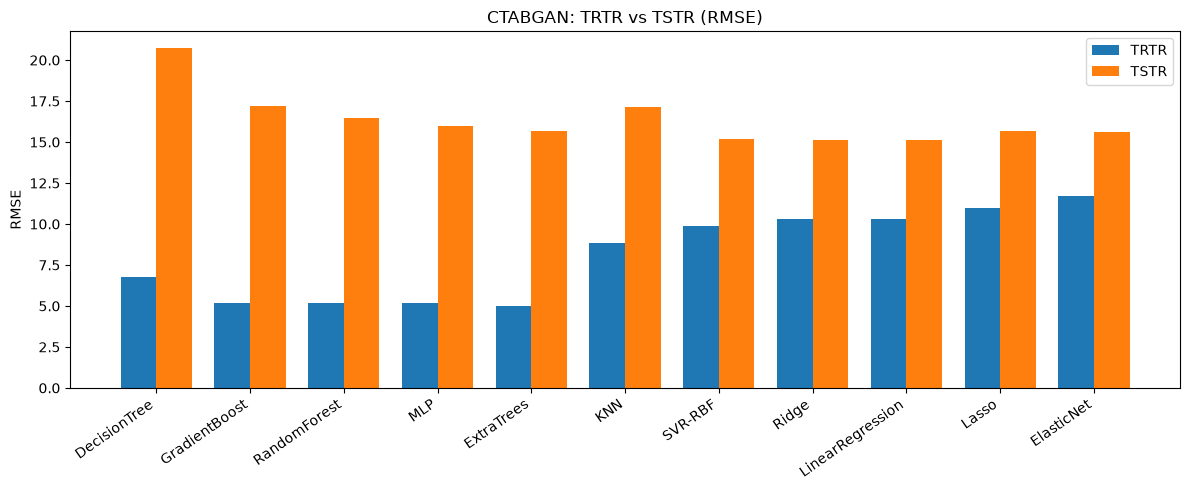

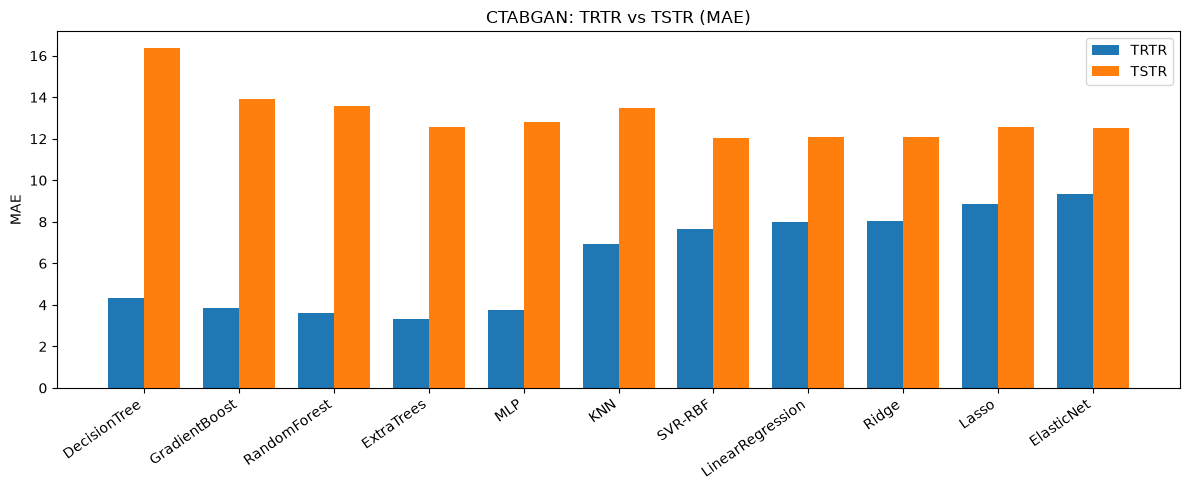

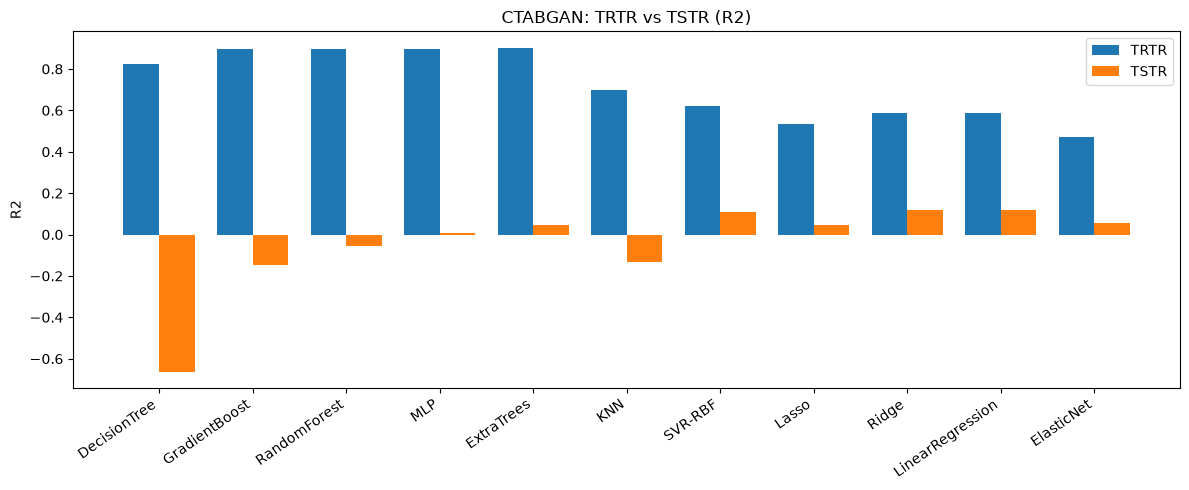

WGAN_GP - TSTR (Train Synthetic, Test Real)


,Model,MAE,RMSE,R2
0,LinearRegression,13.154463,15.285586,0.094789
1,Ridge,13.184251,15.326176,0.089975
2,MLP,13.615418,16.101572,-0.004436
3,SVR-RBF,13.379700,16.118721,-0.006577
4,ElasticNet,13.708327,16.392788,-0.041097
5,GradientBoost,14.080253,16.537366,-0.059543
6,ExtraTrees,14.089828,16.678935,-0.077761
7,RandomForest,14.232314,16.818297,-0.095847
8,Lasso,14.155399,16.879597,-0.103849
9,KNN,14.717247,17.480964,-0.183904


WGAN_GP - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,MAE_Diff,R2_Drop,Synthetic_Model
0,ExtraTrees,3.305280,4.990639,0.903506,14.089828,16.678935,-0.077761,11.688296,10.784548,0.981267,WGAN_GP
1,GradientBoost,3.853346,5.157510,0.896946,14.080253,16.537366,-0.059543,11.379856,10.226907,0.956488,WGAN_GP
2,RandomForest,3.586209,5.159141,0.896881,14.232314,16.818297,-0.095847,11.659156,10.646105,0.992727,WGAN_GP
3,MLP,3.732953,5.198912,0.895285,13.615418,16.101572,-0.004436,10.902660,9.882465,0.899721,WGAN_GP
4,DecisionTree,4.336200,6.756412,0.823145,15.907446,19.461315,-0.467338,12.704903,11.571246,1.290482,WGAN_GP
5,KNN,6.929950,8.837354,0.697427,14.717247,17.480964,-0.183904,8.643609,7.787297,0.881331,WGAN_GP
6,SVR-RBF,7.664849,9.874375,0.622250,13.379700,16.118721,-0.006577,6.244346,5.714851,0.628826,WGAN_GP
7,Ridge,8.020439,10.296901,0.589230,13.184251,15.326176,0.089975,5.029275,5.163812,0.499255,WGAN_GP
8,LinearRegression,8.015265,10.299603,0.589014,13.154463,15.285586,0.094789,4.985983,5.139198,0.494226,WGAN_GP
9,Lasso,8.857823,10.994591,0.531679,14.155399,16.879597,-0.103849,5.885006,5.297576,0.635528,WGAN_GP


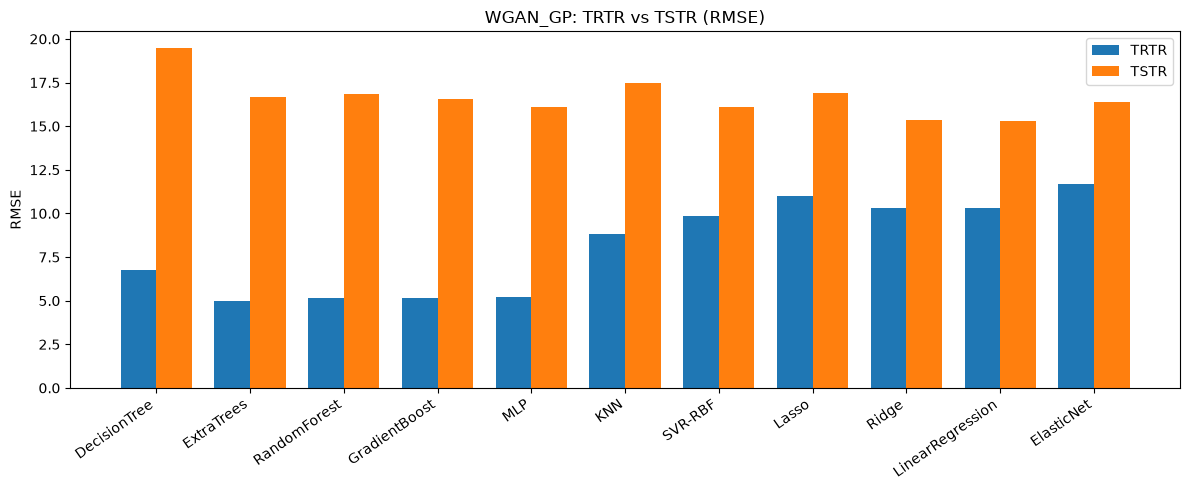

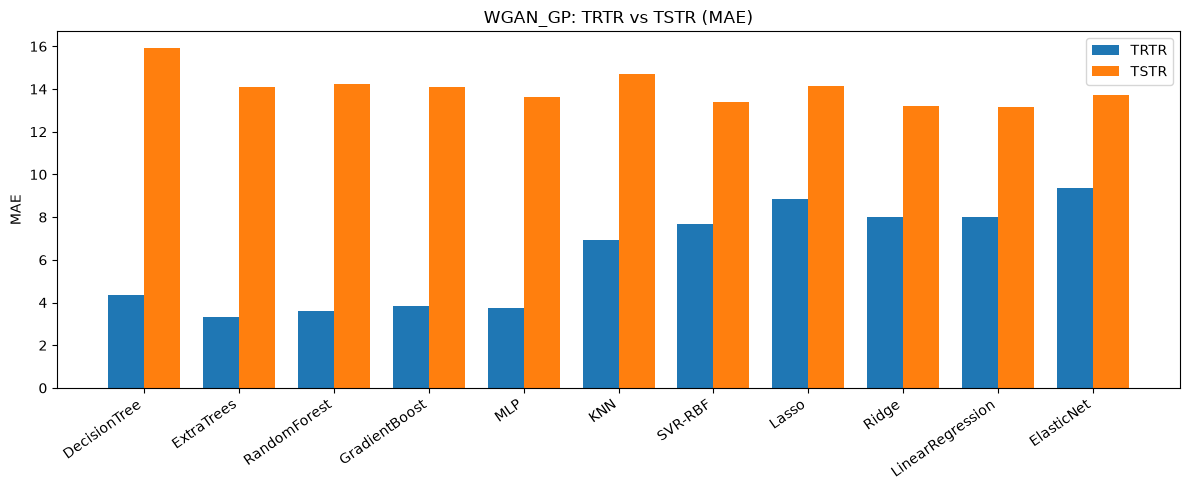

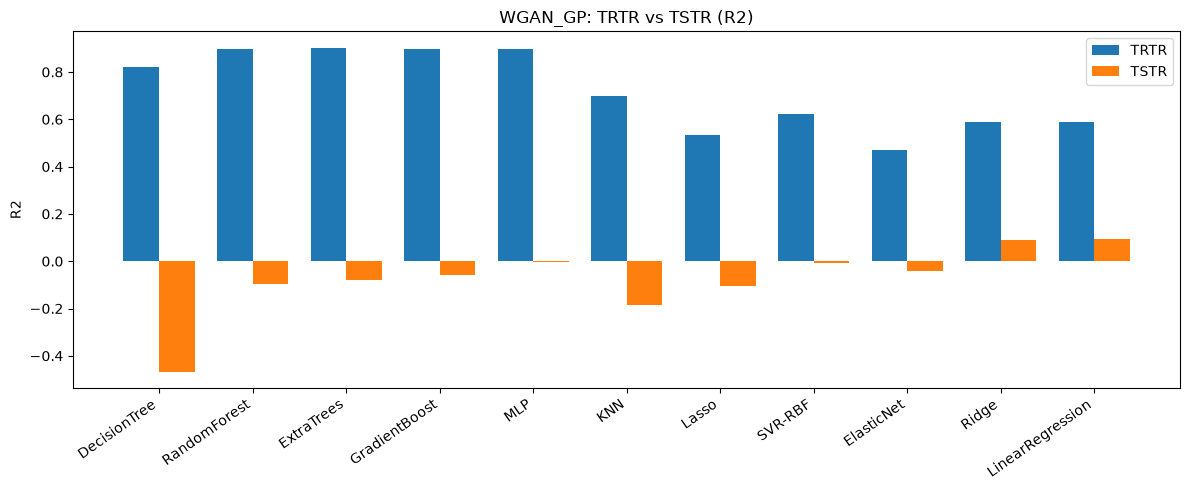

Average RMSE increase by synthetic generator (lower is better):


,Synthetic_Model,RMSE_Diff
0,CTABGAN,8.240682
1,WGAN_GP,8.529913


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="RMSE"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return
    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]], on="Model", suffixes=("_TRTR", "_TSTR")
    )
    df["Diff"] = (
        df[f"{metric}_TSTR"] - df[f"{metric}_TRTR"]
        if metric in ["MAE", "RMSE"]
        else df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    )
    df = df.sort_values("Diff", ascending=False)
    x = np.arange(len(df))
    w = 0.38
    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label="TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label="TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

label_col = "Concrete compressive strength"
model_order = ["CTABGAN", "WGAN_GP"]

trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comp = []
for synth_name in model_order:
    synth_df = synthetic_outputs[synth_name].copy()
    _common = [c for c in data.columns if c in synth_df.columns]
    synth_train = synth_df[_common]
    tstr_results = evaluate_models(train_df=synth_train, test_df=data, label=label_col, models=models)
    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)
    comparison = trtr_results.merge(tstr_results, on="Model", suffixes=("_TRTR", "_TSTR"))
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)
    all_comp.append(comparison)
    for metric in ["RMSE", "MAE", "R2"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric)

combined_comparison = pd.concat(all_comp, ignore_index=True)
summary = (
    combined_comparison.groupby("Synthetic_Model", as_index=False)["RMSE_Diff"]
    .mean()
    .sort_values("RMSE_Diff")
)
print("Average RMSE increase by synthetic generator (lower is better):")
display(summary)


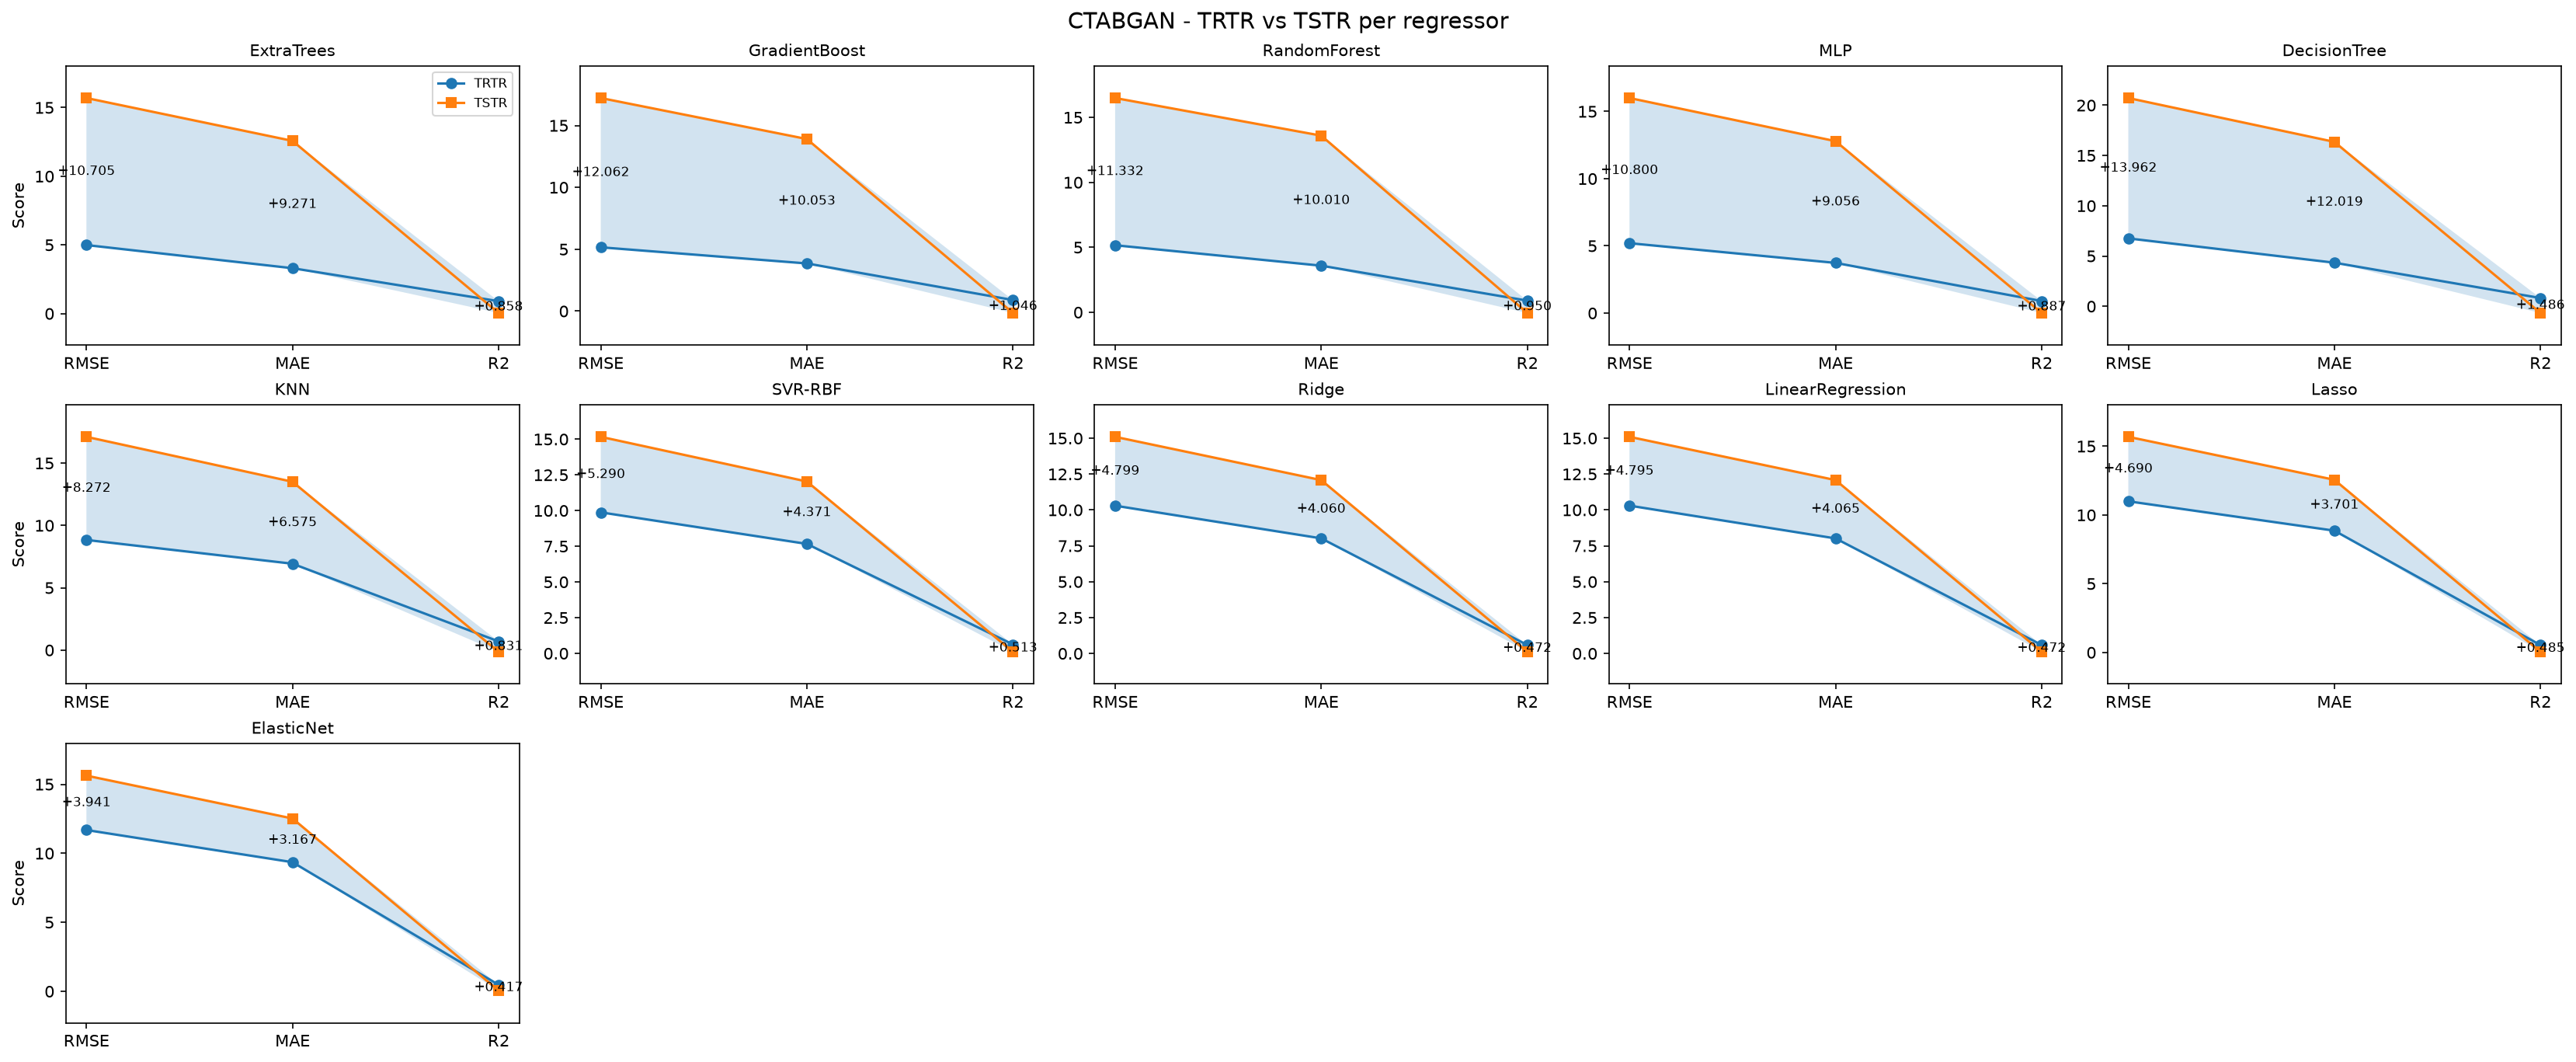

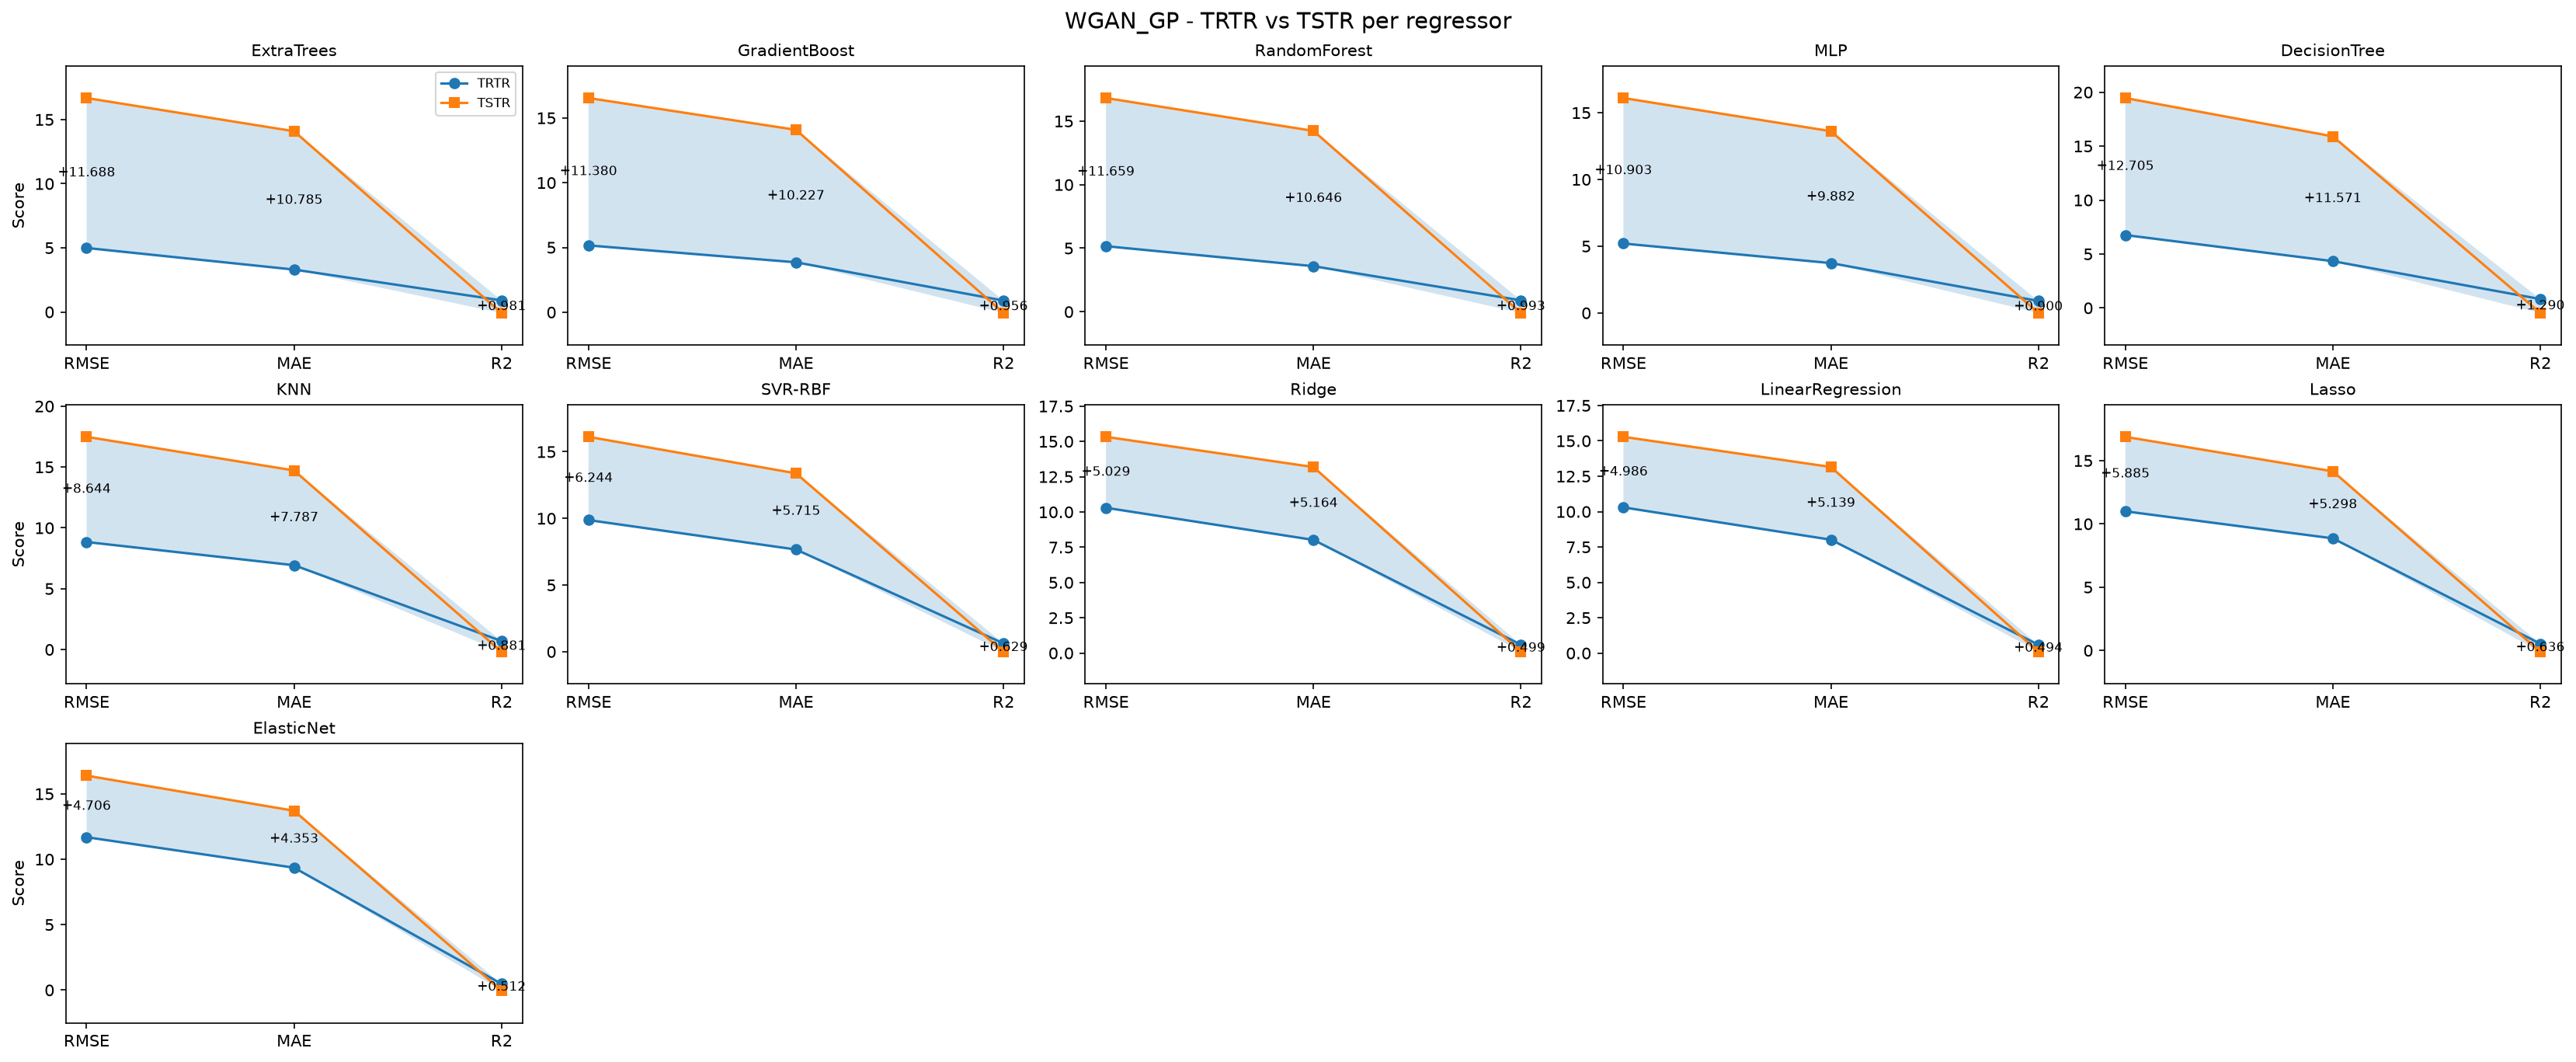

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def _metric_delta(metric, trtr_val, tstr_val):
    if metric in ("RMSE", "MAE"):
        return tstr_val - trtr_val
    if metric == "R2":
        return trtr_val - tstr_val
    return trtr_val - tstr_val

def plot_grid_line_metrics_with_gap(trtr_results, tstr_results, generator_name, ncols=5):
    metrics = [m for m in ["RMSE", "MAE", "R2"] if m in trtr_results.columns and m in tstr_results.columns]
    if not metrics:
        print(f"No common metrics found for {generator_name}.")
        return

    x = np.arange(len(metrics))
    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, max(9, 3 * nrows)), dpi=150, constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, model_name in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[model_name].values.astype(float)
        b = tstr.loc[model_name].values.astype(float)
        deltas = [_metric_delta(m, ai, bi) for m, ai, bi in zip(metrics, a, b)]

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="s", label="TSTR")
        ax.fill_between(x, np.minimum(a, b), np.maximum(a, b), alpha=0.2)

        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        for xi, ai, bi, di in zip(x, a, b, deltas):
            ax.text(xi, (ai + bi) / 2, f"{di:+.3f}", ha="center", va="center", fontsize=8)

        ax.set_title(model_name, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="best")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{generator_name} - TRTR vs TSTR per regressor", fontsize=14)
    plt.show()

label_col = "Concrete compressive strength"
model_order = ["CTABGAN", "WGAN_GP"]
trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
for synth_name in model_order:
    synth_df = synthetic_outputs[synth_name].copy()
    _common = [c for c in data.columns if c in synth_df.columns]
    tstr_results = evaluate_models(
        train_df=synth_df[_common],
        test_df=data,
        label=label_col,
        models=models,
    )
    plot_grid_line_metrics_with_gap(trtr_results, tstr_results, generator_name=synth_name, ncols=5)


# 5 Statistical similarity tests

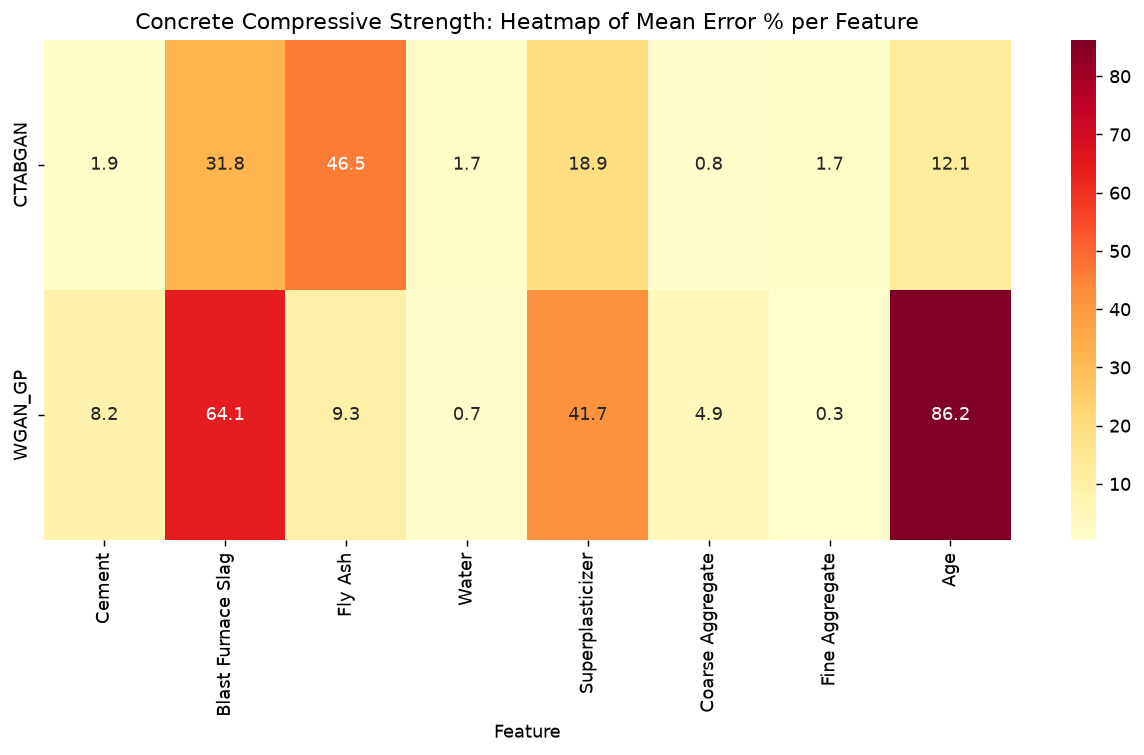

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-ensure model_order and feature_error_by_model exist
model_order = ["CTABGAN", "WGAN_GP"]
target_col = "Concrete compressive strength"
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

feature_error_by_model = {}
for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()
    real_means, synth_means = real_df[num_cols].mean(), synth_df[num_cols].mean()
    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    feature_error_by_model[model_name] = pd.DataFrame({"Feature": num_cols, "Mean_Error_%": mean_error_pct.values})

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T.replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(12, 5), dpi=130)
sns.heatmap(heatmap_df, cmap="YlOrRd", annot=True, fmt=".1f")
plt.title("Concrete Compressive Strength: Heatmap of Mean Error % per Feature")
plt.show()

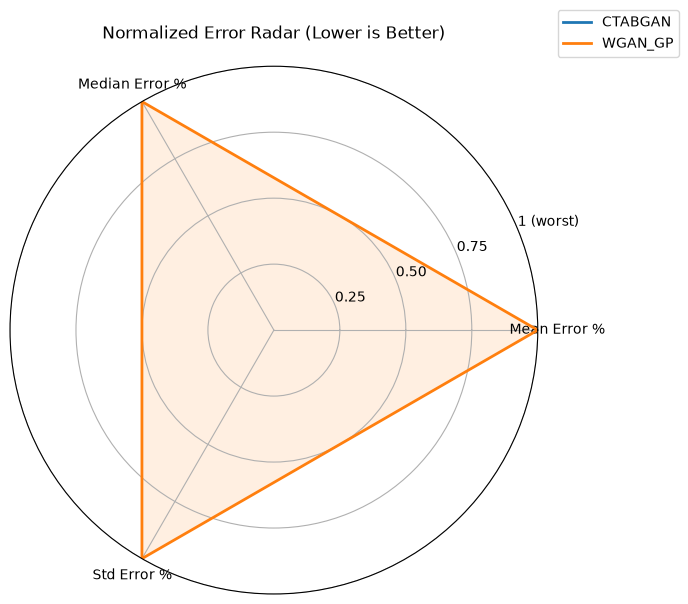

,Model,Mean Error %,Median Error %,Std Error %
0,CTABGAN,14.438487,7.034905,9.932629
1,WGAN_GP,26.940413,8.722670,23.580938


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-calculate the necessary metrics to avoid NameErrors
model_order = ["CTABGAN", "WGAN_GP"]
target_col = "Concrete compressive strength"
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

feature_error_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_outputs[model_name].copy()

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()
    real_stds = real_df[num_cols].std()
    synth_stds = synth_df[num_cols].std()

    # Calculate errors
    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_by_model[model_name] = feature_error_df

    summary_rows.append({
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    })

summary_df = pd.DataFrame(summary_rows)

# 2. Generate the Radar Plot
metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

# Min-max normalize each metric across models (0 = best, 1 = worst)
norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
plt.tight_layout()
plt.show()

display(summary_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,WGAN_GP,9.750,4.5,49
1,CTABGAN,50.875,1.5,384


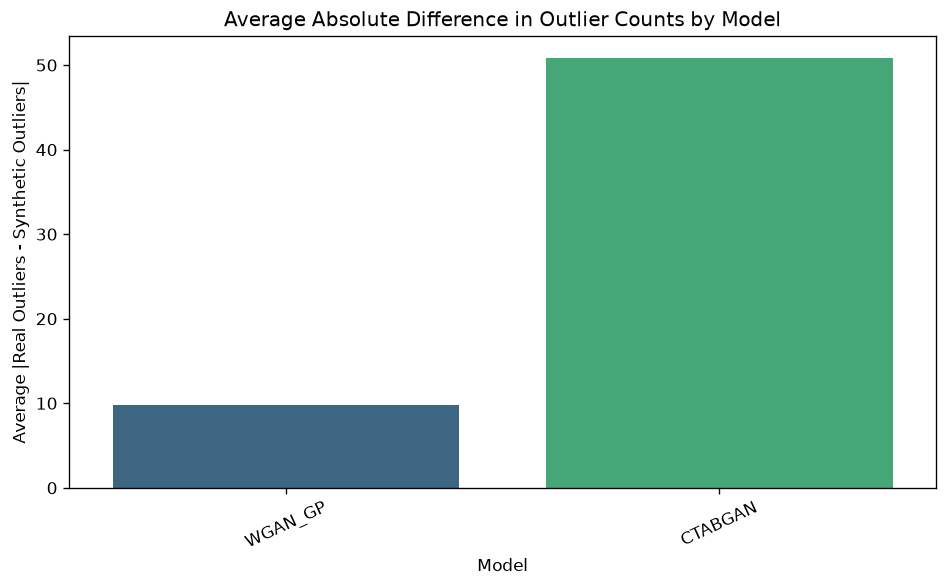

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTABGAN", "WGAN_GP"]

target_col = "Concrete compressive strength"
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_outputs[model].copy()

    # keep only shared columns and numeric features
    common_cols = real_df.columns.intersection(synth_df.columns)
    synth_df = synth_df[common_cols]
    synth_num_cols = [c for c in num_cols if c in synth_df.columns]

    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in synth_num_cols}

    feat_df = pd.DataFrame({
        "Feature": synth_num_cols,
        "Real_Outliers": [real_outliers[c] for c in synth_num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in synth_num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].mean(),
        "Median_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].median(),
        "Max_Abs_Diff_Outlier_Count": feat_df["Abs_Diff_Outlier_Count"].max()
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# 6. Cosine Similarity with Hungraian Mapping

In [ ]:
from numpy.linalg import norm
import numpy as np
import pandas as pd

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def cosine_similarity_matrix(real_df, synth_df, num_cols=None, target_col=None):
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col is None:
        target_col = "Concrete compressive strength"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

synthetic_data = synthetic_outputs

cosine_results = {}
cosine_dfs = {}

model_order = ["WGAN_GP", "CTABGAN"]
target_col = "Concrete compressive strength"
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=float))

for model_name in model_order:
    if model_name not in synthetic_data:
        raise KeyError(f"{model_name} not found in synthetic_data. Available keys: {list(synthetic_data.keys())}")

    synth_df = synthetic_data[model_name].copy()

    missing_cols = [c for c in data.columns if c not in synth_df.columns]
    if missing_cols:
        raise ValueError(f"{model_name} is missing columns: {missing_cols}")

    synth_df = synth_df[data.columns].copy()
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=float))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)


In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    target_col = "Concrete compressive strength"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")


WGAN_GP - Top 10 Real -> Synthetic Matchings
01. R604 -> S819   cosine similarity = 1.0000
02. R356 -> S985   cosine similarity = 1.0000
03. R451 -> S985   cosine similarity = 1.0000
04. R267 -> S985   cosine similarity = 1.0000
05. R423 -> S634   cosine similarity = 1.0000
06. R959 -> S784   cosine similarity = 1.0000
07. R121 -> S818   cosine similarity = 1.0000
08. R846 -> S57   cosine similarity = 1.0000
09. R753 -> S497   cosine similarity = 1.0000
10. R757 -> S383   cosine similarity = 1.0000

CTABGAN - Top 10 Real -> Synthetic Matchings
01. R363 -> S462   cosine similarity = 1.0000
02. R991 -> S10   cosine similarity = 1.0000
03. R12 -> S715   cosine similarity = 1.0000
04. R518 -> S978   cosine similarity = 1.0000
05. R923 -> S892   cosine similarity = 1.0000
06. R186 -> S124   cosine similarity = 1.0000
07. R298 -> S835   cosine similarity = 1.0000
08. R970 -> S642   cosine similarity = 1.0000
09. R169 -> S288   cosine similarity = 1.0000
10. R549 -> S283   cosine similarity 

In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    target_col = "Concrete compressive strength"
    if target_col in num_cols:
        num_cols.remove(target_col)

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()

synthetic_data = synthetic_outputs

results = {}

for name, synth_df in synthetic_data.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features)")
    print(f"==============================")

    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common].copy()

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")

summary_df = pd.DataFrame(
    [{"Model": name, "Avg_Hungarian_Cosine": info["avg_similarity"]} for name, info in results.items()]
).sort_values("Avg_Hungarian_Cosine", ascending=False)

display(summary_df)


In [ ]:
import pandas as pd
import numpy as np

# Install xlsxwriter if not already installed
!pip install xlsxwriter

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

target_col = "Concrete compressive strength"
if target_col in feature_cols:
    feature_cols.remove(target_col)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

model_order = ["WGAN_GP", "CTABGAN"]  # ← FIXED: Match your results keys
output_file = "Hungarian_Matchings_All_Models.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            print(f"Skipping {model_name}: no Hungarian results found")
            continue
        if model_name not in synth_source:
            print(f"Skipping {model_name}: no synthetic data found")
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)
        display(summary_df)  # ← FIXED: Moved inside with block

print(f"Saved: {output_file}")

,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
1,CTABGAN,1000,0.980089,0.998310,0.762524,0.999975
0,WGAN_GP,1000,0.976834,0.997062,-0.487305,0.999452


Saved: Hungarian_Matchings_All_Models.xlsx


# 7. Mahalanobis distance with Hungrain Mapping  

In [ ]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

target_col = "Concrete compressive strength"

data_numeric = data.select_dtypes(include=[np.number]).dropna().copy()
if target_col in data_numeric.columns:
    data_numeric = data_numeric.drop(columns=[target_col])

real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (11,), Inv_cov shape: (11, 11)


In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import mahalanobis

# 1. Define target and features FIRST to ensure consistent dimensions
target_col = "Concrete compressive strength"
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

# 2. Compute real distribution statistics using the correct feature subset
real_numeric = data[num_cols].to_numpy(dtype=float)
mu_real = np.mean(real_numeric, axis=0)
cov_real = np.cov(real_numeric, rowvar=False)
inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))  # Stabilize

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

mahalanobis_results = {}
available_models = []

for name in ["WGAN_GP", "CTABGAN"]:
    if name in synth_source:
        # Ensure we use the exact same columns for the synthetic data
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # Compute Mahalanobis distances (dimensions now match: 11 vs 11)
        dists = [mahalanobis(x, mu_real, inv_cov_real) for x in synth_numeric]
        dists = np.array(dists)

        mahalanobis_results[name] = {
            "mean": float(np.mean(dists)),
            "median": float(np.median(dists)),
            "std": float(np.std(dists)),
            "min": float(np.min(dists)),
            "max": float(np.max(dists)),
            "distances": dists,
        }
        available_models.append(name)
        print(f"✓ {name}: mean Mahalanobis = {np.mean(dists):.3f}")
    else:
        print(f"✗ {name} not found in synthetic source.")

# Create summary only for available models
if mahalanobis_results:
    summary = pd.DataFrame({
        name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
        for name, r in mahalanobis_results.items()
    }, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

    summary.index.name = "Model"
    summary = summary.sort_values("mean_dist")

    print("\nMahalanobis distance to real distribution (lower is better):")
    display(summary)
else:
    print("No valid synthetic data found for Mahalanobis analysis.")

✓ WGAN_GP: mean Mahalanobis = 3.987
✓ CTABGAN: mean Mahalanobis = 4.334

Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
WGAN_GP,3.986594,3.698344,1.485355,0.951402,10.417075
CTABGAN,4.333710,4.097737,1.420905,1.576299,11.781783


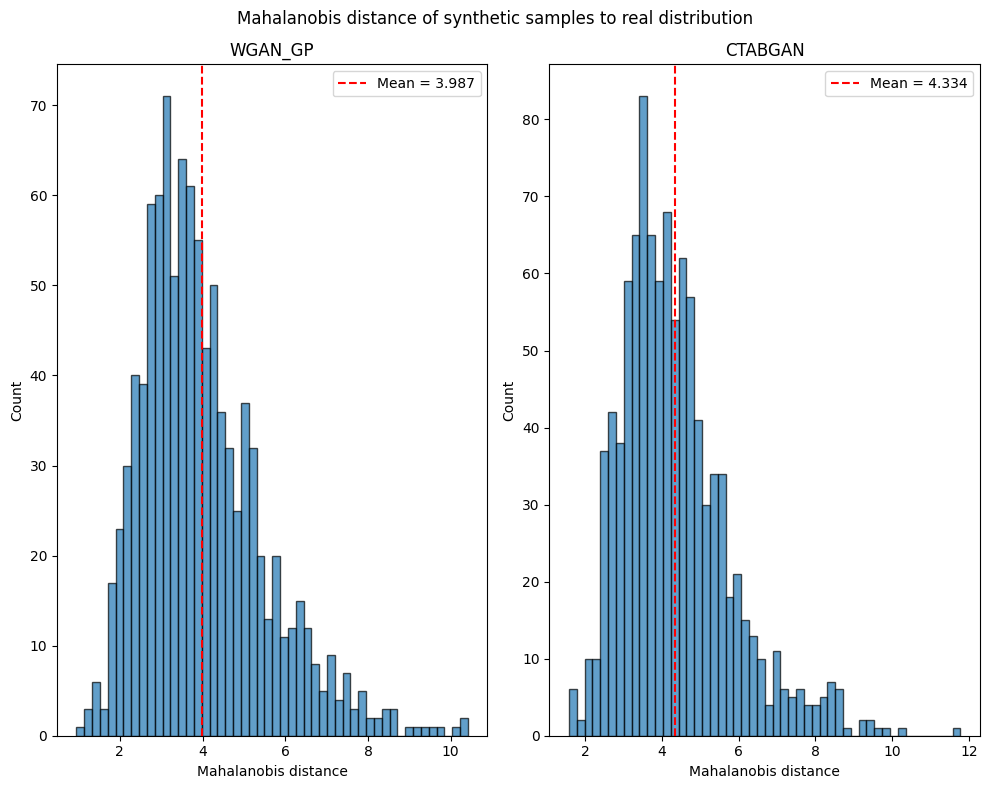

In [ ]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_cancer_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Compute numeric features (exclude target)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

# Compute real covariance inverse (if not already done)
if 'inv_cov_real' not in globals():
    cov_real = np.cov(real_matrix, rowvar=False)
    inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Updated for your models
for name in ["WGAN_GP", "CTABGAN"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # REMOVED size check - use min(real, synth) samples
        n_matches = min(real_matrix.shape[0], synth_numeric.shape[0])
        print(f"✓ Processing {name} ({n_matches} matches from {synth_numeric.shape[0]} synth samples)")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary table (only for successful models)
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")

✓ Processing WGAN_GP (1000 matches from 1000 synth samples)
✓ Processing CTABGAN (1000 matches from 1000 synth samples)
Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
CTABGAN,3.120268,2.854624,1.318368,12.805315,1000.0
WGAN_GP,3.389107,3.111163,1.480250,17.030145,1000.0


In [ ]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_outputs`, `synthetic_data`, or `synthetic_tables`.")

# Compute numeric features (exclude target)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

# Compute real covariance inverse (if not already done)
if 'inv_cov_real' not in globals():
    cov_real = np.cov(real_matrix, rowvar=False)
    inv_cov_real = np.linalg.inv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

hungarian_results = {}
available_models = []

# Your GAN models
for name in ["WGAN_GP", "CTABGAN"]:
    if name in synth_source:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        # REMOVED size check - Hungarian handles rectangular matrices automatically
        n_real, n_synth = real_matrix.shape[0], synth_numeric.shape[0]
        n_matches = min(n_real, n_synth)
        print(f"✓ Processing {name}: {n_real} real vs {n_synth} synth → {n_matches} matches")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        row_ind, col_ind = linear_sum_assignment(D)
        matched_distances = D[row_ind, col_ind]

        hungarian_results[name] = {
            "total_distance": float(matched_distances.sum()),
            "mean_distance_per_match": float(matched_distances.mean()),
            "median_distance_per_match": float(np.median(matched_distances)),
            "std_distance_per_match": float(np.std(matched_distances)),
            "max_distance_per_match": float(matched_distances.max()),
            "matched_distances": matched_distances,
            "row_ind": row_ind,
            "col_ind": col_ind,
            "n_real": n_real,
            "n_synth": n_synth,
            "n_matches": n_matches
        }
        available_models.append(name)
    else:
        print(f"✗ {name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary table (only for successful models)
if hungarian_results:
    hungarian_summary = pd.DataFrame(
        {
            name: [
                r["mean_distance_per_match"],
                r["median_distance_per_match"],
                r["std_distance_per_match"],
                r["max_distance_per_match"],
                r["n_matches"]
            ]
            for name, r in hungarian_results.items()
        },
        index=[
            "mean_distance_per_match",
            "median_distance_per_match",
            "std_distance_per_match",
            "max_distance_per_match",
            "n_matches"
        ],
    ).T

    hungarian_summary.index.name = "Model"
    hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

    print("Hungarian matching using Mahalanobis distance (lower is better):")
    display(hungarian_summary)
else:
    print("No valid models found for Mahalanobis Hungarian matching.")

✓ Processing WGAN_GP: 1000 real vs 1000 synth → 1000 matches
✓ Processing CTABGAN: 1000 real vs 1000 synth → 1000 matches
Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match,n_matches
Model,,,,,
CTABGAN,3.120268,2.854624,1.318368,12.805315,1000.0
WGAN_GP,3.389107,3.111163,1.480250,17.030145,1000.0


In [ ]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

# Smart synthetic source detection (same as previous cells)
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

# Use same numeric columns as previous Mahalanobis cell
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)

real_matrix = data[num_cols].to_numpy(dtype=float)

greedy_results = {}
comparison_rows = []

# Your GAN models
for name in ["WGAN_GP", "CTABGAN"]:
    if name in synth_source and name in hungarian_results:
        synth_df = synth_source[name][num_cols].copy()
        synth_numeric = synth_df.to_numpy(dtype=float)

        print(f"✓ Processing {name}: {real_matrix.shape[0]} real vs {synth_numeric.shape[0]} synth")

        D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
        total_g, mean_g, _ = greedy_one_to_one_matching(D)

        greedy_results[name] = {
            "total_distance": total_g,
            "mean_distance": mean_g
        }

        # Compare with Hungarian results
        h_total = hungarian_results[name]["total_distance"]
        h_mean = hungarian_results[name]["mean_distance_per_match"]

        comparison_rows.append({
            "Model": name,
            "Greedy total": total_g,
            "Hungarian total": h_total,
            "Greedy mean": mean_g,
            "Hungarian mean": h_mean,
            "Total diff (Greedy - Hungarian)": total_g - h_total,
            "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
        })
        print(f"  Greedy mean: {mean_g:.4f} vs Hungarian: {h_mean:.4f} (diff: {mean_g-h_mean:.4f})")
    else:
        print(f"✗ Skipping {name} (missing data or Hungarian results)")

# Greedy summary
if greedy_results:
    greedy_summary = pd.DataFrame({
        name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
        for name in greedy_results
    }, index=["total_distance", "mean_distance"]).T
    greedy_summary.index.name = "Model"

    print("Greedy one-to-one matching (Mahalanobis distance):")
    display(greedy_summary)

    print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
    comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
    display(comparison_df)
else:
    print("No valid models for greedy matching.")

✓ Processing WGAN_GP: 1000 real vs 1000 synth
  Greedy mean: 3.6759 vs Hungarian: 3.3891 (diff: 0.2868)
✓ Processing CTABGAN: 1000 real vs 1000 synth
  Greedy mean: 3.3377 vs Hungarian: 3.1203 (diff: 0.2175)
Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
WGAN_GP,3675.944528,3.675945
CTABGAN,3337.727241,3.337727



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
WGAN_GP,3675.944528,3389.107322,3.675945,3.389107,286.837207,0.286837
CTABGAN,3337.727241,3120.268299,3.337727,3.120268,217.458942,0.217459


In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Use your data and dynamic target detection
real_df = data.copy()

feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]

X_real = real_df[feature_cols].to_numpy(dtype=float)

# Covariance with regularization (pinv is better than inv for stability)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models
model_order = ["WGAN_GP", "CTABGAN"]
hungarian_results = {}

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][real_df.columns].copy()
        X_synth = synth_df[feature_cols].to_numpy(dtype=float)

        print(f"✓ Processing {model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")

        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Hungarian handles rectangular matrices automatically
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        hungarian_results[model_name] = {
            "row_ind": row_ind,
            "col_ind": col_ind,
            "dists": dists
        }

        # Top matches
        order = np.argsort(dists)
        top_k = min(20, len(order))
        print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
        for rank, k in enumerate(order[:top_k], 1):
            print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")
    else:
        print(f"✗ {model_name} not in synthetic source. Available: {list(synth_source.keys())}")

# Summary stats
if hungarian_results:
    summary_stats = pd.DataFrame({
        model_name: {
            "mean_dist": np.mean(hungarian_results[model_name]["dists"]),
            "median_dist": np.median(hungarian_results[model_name]["dists"]),
            "min_dist": np.min(hungarian_results[model_name]["dists"])
        }
        for model_name in hungarian_results
    }).T.sort_values("mean_dist")
    print("\nSummary Mahalanobis distances (lower is better):")
    display(summary_stats)

✓ Processing WGAN_GP: 1000 real vs 1000 synth

WGAN_GP - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R43 -> S668   distance = 0.9161
02. R908 -> S22   distance = 1.0042
03. R597 -> S776   distance = 1.0088
04. R478 -> S61   distance = 1.0679
05. R717 -> S577   distance = 1.1662
06. R978 -> S676   distance = 1.2387
07. R888 -> S882   distance = 1.2474
08. R807 -> S827   distance = 1.2591
09. R683 -> S19   distance = 1.3369
10. R434 -> S38   distance = 1.3392
11. R967 -> S283   distance = 1.3544
12. R830 -> S301   distance = 1.3568
13. R23 -> S360   distance = 1.3586
14. R359 -> S744   distance = 1.3679
15. R493 -> S379   distance = 1.3871
16. R845 -> S216   distance = 1.3902
17. R623 -> S219   distance = 1.3917
18. R846 -> S57   distance = 1.3999
19. R802 -> S907   distance = 1.4168
20. R556 -> S895   distance = 1.4230
✓ Processing CTABGAN: 1000 real vs 1000 synth

CTABGAN - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R831 -> S495   distance = 0.8090


,mean_dist,median_dist,min_dist
CTABGAN,3.120268,2.854624,0.808957
WGAN_GP,3.389107,3.111163,0.916053


In [ ]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import pandas as pd

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

# Use your data with dynamic target detection
real_df = data.copy()

feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]

X_real = real_df[feature_cols].to_numpy(dtype=float)

# Covariance with regularization
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

# Your GAN models
model_order = ["WGAN_GP", "CTABGAN"]

for model_name in model_order:
    if model_name in synth_source:
        synth_df = synth_source[model_name][real_df.columns].copy()
        X_synth = synth_df[feature_cols].to_numpy(dtype=float)

        print(f"\n{'='*60}")
        print(f"{model_name}: {X_real.shape[0]} real vs {X_synth.shape[0]} synth")
        print(f"{'='*60}")

        D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
        D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

        # Simplified Hungarian (handles rectangular matrices automatically)
        row_ind, col_ind = linear_sum_assignment(D)
        dists = D[row_ind, col_ind]

        r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

        print(f"{model_name} - Hungarian mappings for R1 to R20:")
        for r in range(20):
            if r in r_to_match:
                s, dist = r_to_match[r]
                print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
            else:
                print(f"R{r+1} -> No match found")

        # Summary stats for this model
        print(f"  Summary: mean={np.mean(dists):.4f}, median={np.median(dists):.4f}, min={np.min(dists):.4f}")
    else:
        print(f"✗ {model_name} not in synthetic source. Available: {list(synth_source.keys())}")


WGAN_GP: 1000 real vs 1000 synth
WGAN_GP - Hungarian mappings for R1 to R20:
R1 -> S777   distance = 4.3377
R2 -> S132   distance = 5.4128
R3 -> S305   distance = 2.4288
R4 -> S234   distance = 3.0842
R5 -> S15   distance = 5.2455
R6 -> S695   distance = 2.1489
R7 -> S829   distance = 5.5018
R8 -> S857   distance = 3.9000
R9 -> S330   distance = 2.1677
R10 -> S140   distance = 1.8909
R11 -> S249   distance = 6.0484
R12 -> S429   distance = 2.9334
R13 -> S642   distance = 3.9280
R14 -> S543   distance = 3.3440
R15 -> S597   distance = 3.5557
R16 -> S282   distance = 1.5852
R17 -> S654   distance = 3.1224
R18 -> S580   distance = 3.5689
R19 -> S499   distance = 2.3550
R20 -> S393   distance = 3.1175
  Summary: mean=3.3891, median=3.1112, min=0.9161

CTABGAN: 1000 real vs 1000 synth
CTABGAN - Hungarian mappings for R1 to R20:
R1 -> S997   distance = 2.9015
R2 -> S757   distance = 3.1394
R3 -> S672   distance = 2.3559
R4 -> S425   distance = 3.4467
R5 -> S975   distance = 3.9027
R6 -> S31


Processing WGAN_GP: 1000 real vs 1000 synth


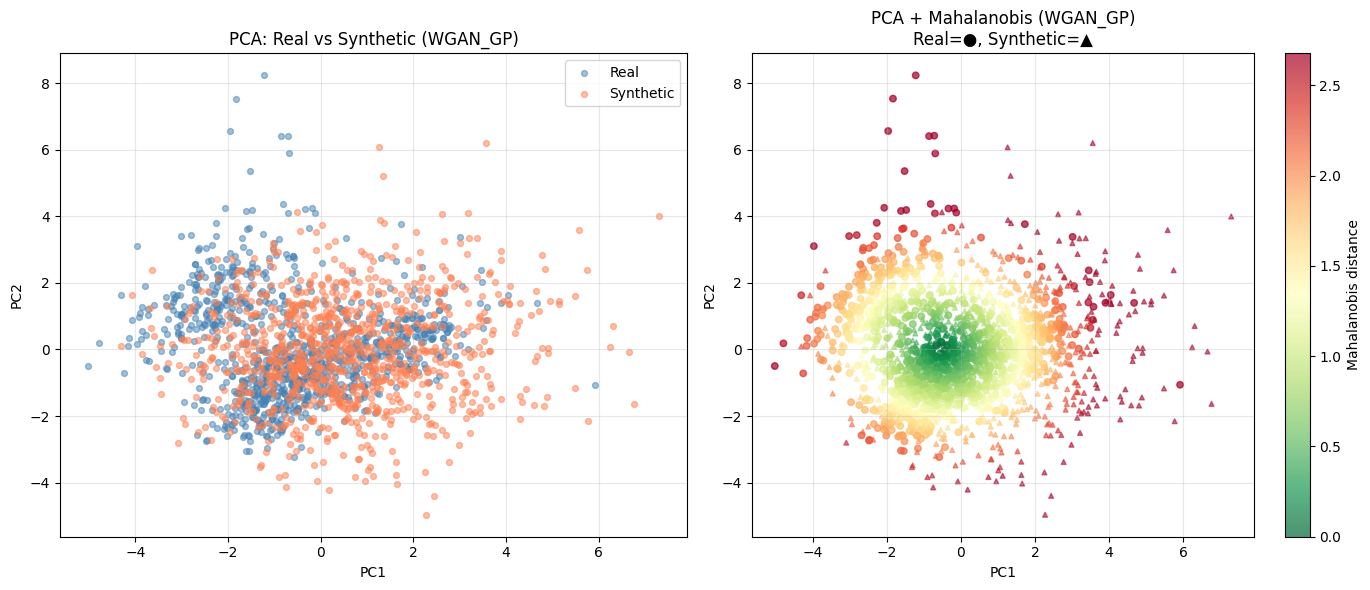

  Real mean MD: 1.2592, Synth mean MD: 1.4262, Delta: +0.1671

Processing CTABGAN: 1000 real vs 1000 synth


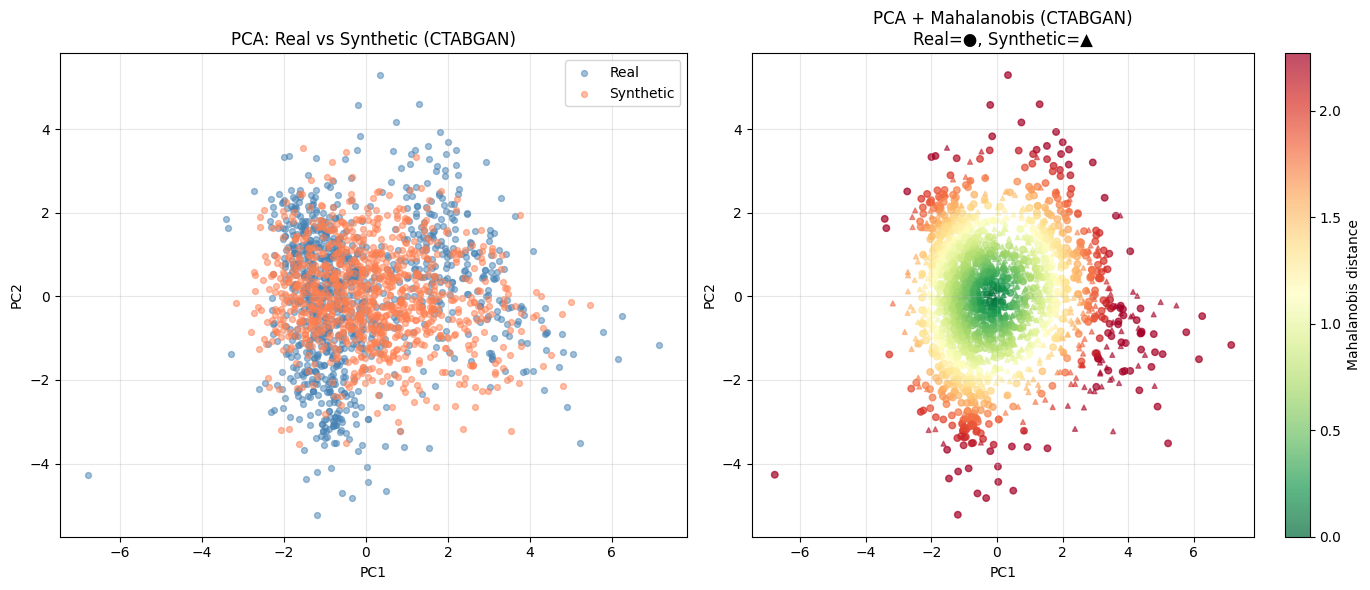

  Real mean MD: 1.2519, Synth mean MD: 1.0165, Delta: -0.2354

Summary: PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
1,CTABGAN,1.251885,1.016480,-0.235405
0,WGAN_GP,1.259152,1.426213,0.167062


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

# Smart synthetic source detection
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

# Your data and GAN models
model_order = ["WGAN_GP", "CTABGAN"]
real_df = data.copy()

feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

X_r = real_df[feature_cols].to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic source, skipping.")
        continue

    synth_df = synth_source[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    print(f"\n{'='*60}")
    print(f"Processing {model_name}: {X_r.shape[0]} real vs {X_s.shape[0]} synth")
    print(f"{'='*60}")

    # PCA on combined data
    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    # Mahalanobis in PCA space (real distribution reference)
    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    # Plot 1: PCA scatter
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Mahalanobis distance color-coded
    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Stats
    print(f"  Real mean MD: {d_r.mean():.4f}, Synth mean MD: {d_s.mean():.4f}, Delta: {d_s.mean()-d_r.mean():+.4f}")

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

# Summary table
if rows:
    summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
    print("\nSummary: PCA 2D Mahalanobis distances (lower Synth_Mean_MD_2D = better):")
    display(summary_df)
else:
    print("No valid models found.")

In [ ]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_WGAN_CTABGAN.xlsx"
):
    # Updated for your GAN models
    model_order = ["WGAN_GP", "CTABGAN"]

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                print(f"Skipping {model_name}: missing data or results")
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            # Flexible distance key detection
            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                print(f"No distance array found for {model_name}, skipping")
                continue

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = model_name[:31]  # Excel sheet name limit
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"✓ Exported {len(matched_df)} matches for {model_name}")

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)
            print("\nSummary table:")
            display(summary_df)

    print(f"\n✅ Excel file created: {filename}")

# ---- Run ----
# Smart source detection + your dataset
if "synthetic_outputs" in globals():
    synth_source = synthetic_outputs
elif "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found.")

real_df = data.copy()

num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != target_col]

print(f"Dataset: {len(real_df)} samples, {len(num_cols)} numeric features")
print(f"Target column: {target_col}")

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synth_source,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_WGAN_CTABGAN.xlsx"
)


Dataset: 1000 samples, 11 numeric features
Target column: quality
✓ Exported 1000 matches for WGAN_GP
✓ Exported 1000 matches for CTABGAN

Summary table:


,Model,Num_Matches,Mean_Distance,Median_Distance,Std_Distance,Min_Distance,Max_Distance
1,CTABGAN,1000,3.120268,2.854624,1.318368,0.808957,12.805315
0,WGAN_GP,1000,3.389107,3.111163,1.480250,0.916053,17.030145



✅ Excel file created: Hungarian_Mahalanobis_WGAN_CTABGAN.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample_regression(model, X, y):
    return (y - model.predict(X)) ** 2

def privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    model.fit(X_train_s, y_train)
    loss_train = model_loss_per_sample_regression(model, X_train_s, y_train)
    loss_test = model_loss_per_sample_regression(model, X_test_s, y_test)
    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    return {"AUC": float(roc_auc_score(labels, scores)), "Advantage": float(np.max(tpr - fpr))}

target_col = "Concrete compressive strength"
feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]
real_df = data.copy()
synth_key = next(iter(synthetic_data)) if "synthetic_data" in globals() else next(iter(synthetic_outputs))
synth_src = synthetic_data if "synthetic_data" in globals() else synthetic_outputs
_common = [c for c in real_df.columns if c in synth_src[synth_key].columns]
synth_df = synth_src[synth_key][_common].copy()
model = Ridge(alpha=1.0, random_state=42)
print(privacy_metrics_mia_regression(
    model,
    real_df[feature_cols].to_numpy(dtype=np.float64),
    real_df[target_col].to_numpy(dtype=np.float64),
    synth_df[feature_cols].to_numpy(dtype=np.float64),
    synth_df[target_col].to_numpy(dtype=np.float64),
))



MIA for WGAN_GP
  AUC: 0.3911
  Advantage: 0.0000
  TPR@FPR=0.01: 0.0020

MIA for CTABGAN
  AUC: 0.4640
  Advantage: 0.0190
  TPR@FPR=0.01: 0.0000

 MIA Results (LOWER AUC = BETTER privacy):


,AUC,Advantage,TPR_at_FPR_001
Model,,,
WGAN_GP,0.391144,0.000,0.002
CTABGAN,0.464033,0.019,0.000


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns
                if c not in ["y"]]
X_train = data[feature_cols].to_numpy(dtype=float)

model_order = ["WGAN_GP", "CTABGAN"]
rows = []

print("Mahalanobis MIA - Real vs Synthetic (WGAN_GP & CTABGAN)")
print("="*70)

for model_name in model_order:
    if model_name not in synth_source:
        print(f"✗ {model_name} not in synthetic source, skipping")
        continue

    print(f"\n✓ Processing {model_name}...")
    X_test = synth_source[model_name][feature_cols].to_numpy(dtype=float)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

# Results table
if rows:
    comparison_df = pd.DataFrame(rows)[
        ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
    ].sort_values("AUC", ascending=False).reset_index(drop=True)

    print("\nMIA (Mahalanobis) Results:")
    print("• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)")
    print("• Train/Test MD: How far synthetic data is from real distribution")
    display(comparison_df)

    # Privacy ranking
    print("\nPrivacy Ranking (LOWER AUC = BETTER privacy):")
    ranked = comparison_df.sort_values("AUC").reset_index(drop=True)
    for idx, row in ranked.iterrows():
        rank_emoji = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
        print(f"{rank_emoji} {row['Model']}: AUC={row['AUC']:.3f}")
else:
    print("No valid models found.")

Mahalanobis MIA - Real vs Synthetic (WGAN_GP & CTABGAN)

✓ Processing WGAN_GP...

✓ Processing CTABGAN...

MIA (Mahalanobis) Results:
• HIGHER AUC = WORSE privacy (easier to distinguish real vs synthetic)
• Train/Test MD: How far synthetic data is from real distribution


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CTABGAN,0.860519,0.578,0.173,3.256921,5.421802
1,WGAN_GP,0.773713,0.426,0.041,3.256921,4.826806



Privacy Ranking (LOWER AUC = BETTER privacy):
🥇 WGAN_GP: AUC=0.774
🥈 CTABGAN: AUC=0.861
